In [92]:
import os, sys
from pathlib import Path
try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(os.path.dirname(notebook_path)))
except Exception:
    pass
sys.path.insert(0, 'utils')
print('cwd:', os.getcwd())

cwd: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [93]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import config

pd.set_option('display.float_format', '{:,.0f}'.format)

LAB_FOLDER   = Path(config.LAB_EXP_FOLDER)
TRAIN_JL     = config.TRAINING_DATA_PATH
RESULT_JL    = config.TRAINING_RESULT_PATH

In [94]:
# ── Dataset ───────────────────────────────────────────────────────────────────
FOLDER = '01_ACA_qdPCR'          # experiment sub-folder; set to None to scan all

# ── Misclassification section ─────────────────────────────────────────────────
MODEL_KEY      = 'cnn_gru_dual'   # key as in config.MODEL_KEY_MAP / results dict
OUTLIER_FILTER = None             # None = baseline; or e.g. 'lstm_ae_pw_ds1_label_elbow'
N_SPLITS       = 5               # must match the n_splits used during training

# Automatically select the correct results file based on n_splits
RESULT_JL = (config.TRAINING_10FOLD_RESULT_PATH if N_SPLITS > 1
             else config.TRAINING_RESULT_PATH)

# ── Plot aesthetics ───────────────────────────────────────────────────────────
CURVE_ALPHA    = 0.04   # individual curve transparency in grid
MAX_CONC_COLS  = 7      # cap grid columns; concentrations are binned if more
FIG_DPI        = 110

# ── Colour map for targets (consistent across all sections) ──────────────────
# Filled in at load time once we know the unique labels.
TARGET_COLORS  = {}     # {label_str: colour}

In [95]:
def _conc_label(v):
    """Human-readable concentration string: 1_000_000 → '1M', 10_000 → '10K', etc."""
    if v >= 1e6:  return f'{v/1e6:.4g}M'
    if v >= 1e3:  return f'{v/1e3:.4g}K'
    return f'{v:.4g}'


def list_available_folders(lab_folder=LAB_FOLDER, train_jl=TRAIN_JL):
    """Return DataFrame of folders that have non-None concentration data."""
    rows = []
    for p in sorted(Path(lab_folder).iterdir()):
        if not p.is_dir(): continue
        jl_path = p / train_jl
        if not jl_path.exists(): continue
        try:
            d = joblib.load(jl_path)
        except Exception:
            continue
        c = d.get('concentration')
        if c is None: continue
        c = np.array(c, dtype=float)
        if np.all(np.isnan(c)): continue
        labels = d['well_labels']
        rows.append({
            'folder': p.name,
            'n_samples': len(labels),
            'n_targets': len(np.unique(labels)),
            'n_conc': len(np.unique(c[~np.isnan(c)])),
            'conc_range': f"{_conc_label(np.nanmin(c))} – {_conc_label(np.nanmax(c))}",
        })
    return pd.DataFrame(rows)


def load_folder_data(folder, lab_folder=LAB_FOLDER, train_jl=TRAIN_JL):
    """Load ori_curves, labels, concentration for *folder*.
    
    Returns dict with keys:
        ori_curves    : (N, T) float ndarray
        labels        : (N,)  str ndarray
        concentration : (N,)  float ndarray  (NaN where missing)
        timestamps    : (T,)  float ndarray or None
        folder        : str
    """
    p = Path(lab_folder) / folder / train_jl
    d = joblib.load(p)

    curves_store = d['curves']
    ori = curves_store['ori_curves'] if isinstance(curves_store, dict) else curves_store

    labels = np.array(d['well_labels'])
    raw_conc = d.get('concentration')
    conc = np.array(raw_conc if raw_conc is not None else [np.nan] * len(labels), dtype=float)
    ts     = np.array(d.get('timestamps', None))
    if ts is not None and ts.ndim > 1: ts = ts[0]   # some fmts store per-curve

    kf_list = d.get('kinetic_features')
    kf = kf_list[0].reset_index(drop=True) if kf_list else None  # index 0 = ori_curves features

    return dict(ori_curves=ori, labels=labels, concentration=conc,
                timestamps=ts, kinetic_features=kf, folder=folder)



def _assign_target_colors(labels):
    """Populate global TARGET_COLORS from tab10, stable across plots in a session."""
    global TARGET_COLORS
    unique = sorted(np.unique(labels))
    palette = plt.get_cmap('tab10').colors
    TARGET_COLORS = {lbl: palette[i % 10] for i, lbl in enumerate(unique)}


# ── Quick overview ────────────────────────────────────────────────────────────
print(list_available_folders().to_string(index=False))

                     folder  n_samples  n_targets  n_conc conc_range
               01_ACA_qdPCR      16188          3       6    5K – 1M
             02_AMCA_qdLAMP      54186          5       7   2K – 10M
              03_AMCA_qdPCR      58598          9       5   1K – 10M
 07_ACA_qdPCR_conc_filtered      15146          3       4   50K – 1M
08_AMCA_qdPCR_conc_filtered      53793          9       3 100K – 10M
               09_Area_Conc      34650          5       3   10K – 1M
              10_Range_Conc      23100          5       3   10K – 1M


In [96]:
def load_results(folder, lab_folder=LAB_FOLDER, result_jl=RESULT_JL):
    """Load classification_performances.joblib for *folder*.
    Returns the inner results dict for the first available curve_type key,
    or None if the file does not exist.
    """
    p = Path(lab_folder) / folder / result_jl
    if not p.exists():
        print(f'[!] Results not found: {p}')
        return None
    return joblib.load(p)


def _get_res_entry(all_results, outlier_filter=None):
    """Navigate the nested results dict to the per-filter entry.
    
    Structure: all_results[curve_type_key][mode_key][outlier_filter]
    Returns (res_entry, curve_type_key, mode_key) or (None, None, None).
    """
    for ct_key, ct_val in all_results.items():
        if not isinstance(ct_val, dict): continue
        for mode_key, mode_val in ct_val.items():
            if not isinstance(mode_val, dict): continue
            if outlier_filter in mode_val:
                return mode_val[outlier_filter], ct_key, mode_key
    return None, None, None


def _reconstruct_fold_conc(labels, concentration, n_splits=N_SPLITS, outlier_filter=None, features_df=None):
    """Reconstruct test-fold sample indices using the same StratifiedKFold used during training.
    
    Returns list of concentration arrays (one per fold), aligned with y_trues_ / y_preds_.
    """
    # Apply outlier filter mask
    if outlier_filter is not None and features_df is not None and outlier_filter in features_df.columns:
        mask = (features_df[outlier_filter] == 1).fillna(False).values
    else:
        mask = np.ones(len(labels), dtype=bool)

    lbl_f = labels[mask]
    con_f = concentration[mask]

    le = LabelEncoder()
    y_enc = le.fit_transform(lbl_f)

    min_class = np.unique(y_enc, return_counts=True)[1].min()
    actual_splits = min(n_splits, min_class)

    splitter = StratifiedKFold(n_splits=actual_splits, shuffle=True, random_state=0)
    fold_concs = []
    fold_labels = []
    for _, test_idx in splitter.split(np.zeros(len(y_enc)), y_enc):
        fold_concs.append(con_f[test_idx])
        fold_labels.append(le.inverse_transform(y_enc[test_idx]))
    return fold_concs, fold_labels, le


def build_prediction_df(res_entry, model_key, fold_concs, fold_labels, le):
    """Concatenate per-fold predictions into a single DataFrame with concentration.
    Columns: true_label, pred_label, concentration, correct.
    """
    pred_key = f'y_preds_{model_key}_'
    if pred_key not in res_entry:
        # Try config lookup
        for pk, _, _ in [config.MODEL_KEY_MAP.get(model_key, (None,)*3)]:
            if pk and pk in res_entry:
                pred_key = pk
                break
        else:
            print(f'[!] Key {pred_key!r} not found in results. Available: {[k for k in res_entry if "preds" in k][:6]}')
            return None

    rows = []
    n_folds = min(len(res_entry['y_trues_']), len(fold_concs))
    for fi in range(n_folds):
        y_true = res_entry['y_trues_'][fi]
        y_pred = res_entry[pred_key][fi]
        conc_f = fold_concs[fi]
        lbl_f  = fold_labels[fi]

        # Decode integer labels → strings if needed
        if isinstance(y_true[0], (int, np.integer)):
            true_strs = le.inverse_transform(y_true)
            pred_strs = le.inverse_transform(y_pred)
        else:
            true_strs, pred_strs = np.array(y_true), np.array(y_pred)

        for j in range(min(len(true_strs), len(conc_f))):
            rows.append(dict(
                true_label=true_strs[j],
                pred_label=pred_strs[j],
                concentration=conc_f[j],
                correct=(true_strs[j] == pred_strs[j]),
                fold=fi,
            ))
    return pd.DataFrame(rows)


def plot_misclassification_by_concentration(
        pred_df, title='', model_key=''):
    """Two panels:
    Left  — accuracy per target × concentration (line plot).
    Right — confusion matrix where rows = (target, conc) and cols = predicted target.
    """
    if pred_df is None or pred_df.empty:
        print('[!] No prediction data available.'); return

    valid = pred_df[~np.isnan(pred_df['concentration'])].copy()
    valid['conc_label'] = valid['concentration'].map(_conc_label)
    unique_tgt  = sorted(valid['true_label'].unique())
    unique_conc = sorted(valid['concentration'].unique())
    conc_lbls   = [_conc_label(c) for c in unique_conc]

    # ── Panel 1: accuracy per target × concentration ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    for tgt in unique_tgt:
        accs = []
        for c in unique_conc:
            sub = valid[(valid['true_label'] == tgt) & (valid['concentration'] == c)]
            accs.append(sub['correct'].mean() if len(sub) > 0 else np.nan)
        color = TARGET_COLORS.get(tgt, 'gray')
        ax.plot(conc_lbls, accs, marker='o', color=color, label=tgt, linewidth=1.5)

    ax.set_xlabel('Concentration')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('Accuracy per target × concentration')
    ax.legend(fontsize=8, title='Target')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.axhline(1 / len(unique_tgt), color='gray', linestyle='--', linewidth=0.8, label='Chance')
    ax.grid(axis='y', alpha=0.3)

    # ── Panel 2: extended confusion matrix ────────────────────────────────────
    ax = axes[1]
    row_labels = [(tgt, _conc_label(c)) for tgt in unique_tgt for c in unique_conc]
    col_labels = unique_tgt

    mat = np.zeros((len(row_labels), len(col_labels)))
    for ri, (tgt, clbl) in enumerate(row_labels):
        sub = valid[(valid['true_label'] == tgt) & (valid['conc_label'] == clbl)]
        if len(sub) == 0: continue
        for ci, pred_tgt in enumerate(col_labels):
            mat[ri, ci] = (sub['pred_label'] == pred_tgt).sum() / len(sub)

    im = ax.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Fraction')

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels([f'{t} / {c}' for t, c in row_labels], fontsize=6)
    ax.set_xlabel('Predicted target')
    ax.set_ylabel('True (target / concentration)')
    ax.set_title('Confusion: true(target,conc) → predicted target')

    # Diagonal markers for correct cells
    for ri, (tgt, _) in enumerate(row_labels):
        if tgt in col_labels:
            ci = col_labels.index(tgt)
            ax.add_patch(plt.Rectangle((ci - 0.5, ri - 0.5), 1, 1,
                                        fill=False, edgecolor='black', lw=0.8))

    fig.suptitle(f'{title} — {model_key} misclassification by concentration', fontsize=11)
    plt.tight_layout()
    plt.show()

In [97]:
from IPython.display import display


In [98]:
from IPython.display import display

_DEFAULT_MODELS = ['cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_trans_dual']

_MODEL_LABELS = {
    'cnn':            'CNN',
    'lstm':           'LSTM',
    'gru':            'GRU',
    'rnn':            'RNN',
    'transformer':    'Transformer',
    'cnn_gru_dual':   'CNN+GRU',
    'cnn_trans_dual': 'CNN+Tr',
    'cnn_lstm_dual':  'CNN+LSTM',
}

# 8-hue palette: ST/MTL pairs, light -> dark with SupCon version
_BAR_PALETTE = [
    ('#b8def5', 'ST'),
    ('#fad7b0', 'MTL'),
    ('#76c1e8', 'ST + SupCon 1'),
    ('#f5ad74', 'MTL + SupCon 1'),
    ('#3498d8', 'ST + SupCon 2'),
    ('#e07c39', 'MTL + SupCon 2'),
    ('#1a6fb5', 'ST + SupCon 3'),
    ('#c05000', 'MTL + SupCon 3'),
]


def plot_stmtl_comparison(res_entry, title='', models=None):
    """8-way grouped bar chart: ST / ST+SC1-3 / MTL / MTL+SC1-3 per model."""
    if res_entry is None:
        print('[!] No results loaded â run Section 5 first.'); return
    if models is None:
        models = _DEFAULT_MODELS

    def _fold_accs(pk):
        return [np.mean(np.array(yt) == np.array(yp)) * 100
                for yt, yp in zip(res_entry.get('y_trues_', []), res_entry.get(pk, []))]

    def _stats(key):
        pk = config.MODEL_KEY_MAP.get(key, (None,))[0]
        if not pk or pk not in res_entry:
            return None, None
        a = _fold_accs(pk)
        return (np.mean(a), np.std(a)) if a else (None, None)

    rows = []
    for base in models:
        label = _MODEL_LABELS.get(base, base)
        st_m, st_s = _stats(base)
        if st_m is None:
            continue
        rows.append(dict(
            name   = label,
            st     = (st_m, st_s),
            sc1    = _stats(base + '_supcon'),
            sc2    = _stats(base + '_supcon2'),
            sc3    = _stats(base + '_supcon3'),
            mtl    = _stats(base + '_mtl'),
            sc1mtl = _stats(base + '_supcon_mtl'),
            sc2mtl = _stats(base + '_supcon2_mtl'),
            sc3mtl = _stats(base + '_supcon3_mtl'),
        ))

    if not rows:
        print('[!] No models found in results.'); return

    _KEYS = ['st', 'mtl', 'sc1', 'sc1mtl', 'sc2', 'sc2mtl', 'sc3', 'sc3mtl']
    n_bars = len(_KEYS)
    n, w = len(rows), 0.10
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * w
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(10, n * 3.2), 5.5))

    for ki, ((color, lbl), offset) in enumerate(zip(_BAR_PALETTE, offsets)):
        key = _KEYS[ki]
        xi = np.array([i for i, r in enumerate(rows) if r[key][0] is not None])
        mi = np.array([r[key][0] for r in rows if r[key][0] is not None])
        si = np.array([r[key][1] for r in rows if r[key][0] is not None])
        if not len(xi):
            continue
        bars = ax.bar(xi + offset, mi, w, yerr=si, color=color,
                      label=lbl, capsize=2, error_kw={'linewidth': 0.8, 'alpha': 0.5})
        for bar, mv, sv in zip(bars, mi, si):
            ax.text(bar.get_x() + w / 2, mv + sv + 0.05, f'{mv:.2f}',
                    ha='center', va='bottom', fontsize=6, color='#444', fontweight='bold')

    all_means = [r[k][0] for r in rows for k in _KEYS if r[k][0] is not None]
    ax.set_ylim(max(0, min(all_means) - 3), min(100, max(all_means) + 4))
    ax.set_xticks(x)
    ax.set_xticklabels([r['name'] for r in rows], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=7.5, loc='lower right', ncol=2)
    ax.grid(axis='y', alpha=0.3, linewidth=0.8)
    ax.set_title(f'{title} â ST / MTL × Base / SupCon 1 / SupCon 2 / SupCon 3', fontsize=11)
    plt.tight_layout()
    plt.show()

    def _fmt(m, s): return f'{m:.2f} ± {s:.2f}' if m is not None else 'â'
    df = pd.DataFrame([{
        'Model':       r['name'],
        'ST (%)':      _fmt(*r['st']),
        'ST+SC1 (%)':  _fmt(*r['sc1']),
        'ST+SC2 (%)':  _fmt(*r['sc2']),
        'ST+SC3 (%)':  _fmt(*r['sc3']),
        'MTL (%)':     _fmt(*r['mtl']),
        'MTL+SC1 (%)': _fmt(*r['sc1mtl']),
        'MTL+SC2 (%)': _fmt(*r['sc2mtl']),
        'MTL+SC3 (%)': _fmt(*r['sc3mtl']),
    } for r in rows])
    display(df.set_index('Model'))


---
## Section 8 · Regression Performance (MTL)

Three panels for each MTL model that has regression results stored:
- **8a** — RMSE, MAE, and R² metric bars (which model predicts concentration best?)
- **8b** — Predicted vs actual scatter in log₁₀ space (are errors systematic?)
- **8c** — Residual = log₁₀(pred/true) by concentration level (are certain bins biased?)

In [99]:
REG_SENTINEL = -1.0   # must match model_utils_mtl.py REG_SENTINEL


def collect_reg_results(res_entry):
    """Collect per-model regression arrays and aggregate metrics.

    Returns a list of dicts (one per MTL model that has reg keys in res_entry):
        model, label, rmse, mae, r2, n_valid, preds (N,), trues (N,)
    Sentinel (-1.0) values are excluded before computing any metric.
    """
    out = []
    # Scan res_entry for any y_reg_preds_*_ key so supcon MTL models are included
    _all_reg_names = sorted(
        k[12:-1] for k in res_entry
        if k.startswith('y_reg_preds_') and k.endswith('_')
    )
    for m_name in _all_reg_names:
        rk = f'y_reg_preds_{m_name}_'
        tk = f'y_reg_trues_{m_name}_'
        if rk not in res_entry or tk not in res_entry:
            continue
        p_folds = res_entry[rk]
        t_folds = res_entry[tk]
        if not p_folds or not t_folds:
            continue
        p_all = np.concatenate(p_folds)
        t_all = np.concatenate(t_folds)
        vm    = t_all != REG_SENTINEL
        if vm.sum() < 2:
            continue
        p, t  = p_all[vm], t_all[vm]
        rmse  = float(np.sqrt(np.mean((p - t) ** 2)))
        mae   = float(np.mean(np.abs(p - t)))
        ss    = float(np.sum((t - t.mean()) ** 2))
        r2    = 1.0 - float(np.sum((t - p) ** 2)) / ss if ss > 0 else 0.0
        out.append(dict(model=m_name,
                        label=config.MODEL_PRINT_MAP.get(m_name, m_name),
                        rmse=rmse, mae=mae, r2=r2,
                        n_valid=int(vm.sum()),
                        preds=p, trues=t))
    return out


def plot_reg_metrics(reg_data, title=''):
    """8a — Horizontal bars: RMSE & MAE (left) and R² (right) per MTL model."""
    if not reg_data:
        print('[!] No regression data — no MTL reg keys found in results.'); return

    names     = [r['label']  for r in reg_data]
    rmse_vals = [r['rmse']   for r in reg_data]
    mae_vals  = [r['mae']    for r in reg_data]
    r2_vals   = [r['r2']     for r in reg_data]
    n         = len(reg_data)
    h         = max(3.5, n * 0.55 + 1.5)

    best_rmse_i = int(np.argmin(rmse_vals))
    best_mae_i  = int(np.argmin(mae_vals))
    best_r2_i   = int(np.argmax(r2_vals))
    _GOLD = '#b8860b'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, h))
    y  = np.arange(n)
    bw = 0.35

    # ── RMSE & MAE ───────────────────────────────────────────────────────────────────────────
    ax1.barh(y + bw / 2, rmse_vals, bw, color='#2a78d6', alpha=0.85, label='RMSE')
    ax1.barh(y - bw / 2, mae_vals,  bw, color='#1baf7a', alpha=0.85, label='MAE')
    for i, (r, m) in enumerate(zip(rmse_vals, mae_vals)):
        rmse_star = ' ★' if i == best_rmse_i else ''
        mae_star  = ' ★' if i == best_mae_i  else ''
        ax1.text(r * 1.01, i + bw / 2, f'{r:,.0f}{rmse_star}', va='center', fontsize=7,
                 color=_GOLD if i == best_rmse_i else '#52514e',
                 fontweight='bold' if i == best_rmse_i else 'normal')
        ax1.text(m * 1.01, i - bw / 2, f'{m:,.0f}{mae_star}',  va='center', fontsize=7,
                 color=_GOLD if i == best_mae_i  else '#52514e',
                 fontweight='bold' if i == best_mae_i  else 'normal')
    ax1.set_yticks(y); ax1.set_yticklabels(names, fontsize=9)
    ax1.invert_yaxis()
    ax1.legend(fontsize=9)
    ax1.set_xlabel('Error (original concentration scale)')
    ax1.set_title('RMSE & MAE per MTL model')
    ax1.grid(axis='x', alpha=0.3, linewidth=0.8)
    ax1.axvline(0, color='#c3c2b7', linewidth=1)

    # ── R² ─────────────────────────────────────────────────────────────────────────────
    ax2.barh(y, r2_vals, 0.5, color='#4a3aa7', alpha=0.85)
    for i, v in enumerate(r2_vals):
        r2_star = ' ★' if i == best_r2_i else ''
        ax2.text(max(v, 0) + 0.01, i, f'{v:.3f}{r2_star}', va='center', fontsize=7.5,
                 color=_GOLD if i == best_r2_i else '#52514e',
                 fontweight='bold' if i == best_r2_i else 'normal')
    ax2.set_yticks(y); ax2.set_yticklabels(names, fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlim(-0.05, 1.08)
    ax2.axvline(0, color='#c3c2b7', linewidth=1)
    ax2.set_xlabel('R²')
    ax2.set_title('R² per MTL model')
    ax2.grid(axis='x', alpha=0.3, linewidth=0.8)

    fig.suptitle(f'{title} — MTL Regression Metrics (original concentration scale)', fontsize=11)
    plt.tight_layout()
    plt.show()

    df_reg = pd.DataFrame([{
        'Model':   r['label'],
        'RMSE':    f"{r['rmse']:,.2f}",
        'MAE':     f"{r['mae']:,.2f}",
        'R²':      f"{r['r2']:.4f}",
        'N valid': r['n_valid'],
    } for r in reg_data])
    display(df_reg.set_index('Model'))


In [100]:
def plot_reg_scatter(reg_data, title='', max_models=9, log10_scale=True):
    """8b — Predicted vs actual scatter, one subplot per model.

    log10_scale=True  (default): axes in log₁₀ space, matching training normalisation.
    log10_scale=False           : axes in original concentration scale.

    Points coloured by true concentration (sequential blue, light→dark = low→high).
    Red dashed identity line (y = x). Square axes so bias is immediately visible.
    Best-performing model on each metric gets ★ in its subplot title.
    """
    if not reg_data:
        print('[!] No regression data.'); return

    best_r2_model   = reg_data[int(np.argmax([r['r2']   for r in reg_data]))]['model']
    best_rmse_model = reg_data[int(np.argmin([r['rmse'] for r in reg_data]))]['model']
    best_mae_model  = reg_data[int(np.argmin([r['mae']  for r in reg_data]))]['model']
    _GOLD = '#b8860b'

    models = reg_data[:max_models]
    ncols  = min(3, len(models))
    nrows  = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(4.5 * ncols, 4.2 * nrows), squeeze=False)

    for i, row in enumerate(models):
        ax = axes[i // ncols][i % ncols]

        if log10_scale:
            p_plot = np.log10(np.maximum(row['preds'], 0.1))
            t_plot = np.log10(np.maximum(row['trues'], 0.1))
            xlabel, ylabel = 'True conc. (log₁₀)', 'Pred. conc. (log₁₀)'
        else:
            p_plot = row['preds']
            t_plot = row['trues']
            xlabel, ylabel = 'True concentration', 'Pred. concentration'

        sc = ax.scatter(t_plot, p_plot, s=5, alpha=0.3,
                        c=t_plot, cmap='Blues',
                        vmin=t_plot.min(), vmax=t_plot.max(),
                        rasterized=True)

        lo = min(t_plot.min(), p_plot.min())
        hi = max(t_plot.max(), p_plot.max())
        ax.plot([lo, hi], [lo, hi], color='#e34948', linewidth=1.2,
                linestyle='--', alpha=0.8)

        unique_c = sorted(np.unique(np.round(row['trues'], 0)))
        if log10_scale:
            ticks = np.log10(np.maximum(unique_c, 0.1))
        else:
            ticks = unique_c
        ax.set_xticks(ticks)
        ax.set_xticklabels([_conc_label(c) for c in unique_c], rotation=30, fontsize=6.5)
        ax.set_yticks(ticks)
        ax.set_yticklabels([_conc_label(c) for c in unique_c], fontsize=6.5)

        stars = ''.join([
            ' ★R²'   if row['model'] == best_r2_model   else '',
            ' ★RMSE' if row['model'] == best_rmse_model else '',
            ' ★MAE'  if row['model'] == best_mae_model  else '',
        ])
        ax.set_title(
            f"{row['label']}{stars}\nRMSE {row['rmse']:,.0f}  MAE {row['mae']:,.0f}  R²={row['r2']:.3f}",
            fontsize=8, color=_GOLD if stars else 'black')
        ax.set_xlabel(xlabel, fontsize=7.5)
        ax.set_ylabel(ylabel, fontsize=7.5)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(alpha=0.3, linewidth=0.8)

    for j in range(len(models), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')

    scale_label = 'log₁₀ scale' if log10_scale else 'original scale'
    fig.suptitle(f'{title} — Predicted vs actual concentration ({scale_label})', fontsize=11)
    plt.tight_layout()
    plt.show()


In [101]:
def plot_reg_residuals(reg_data, title='', max_models=9):
    """8c — Residual = log₁₀(pred/true) per concentration bucket, one panel per model.

    A centred boxplot per concentration shows whether bias is systematic at specific
    levels (median far from 0 = model over/under-predicts that range).
    Blue fill, red median line for fast reading.
    """
    if not reg_data:
        print('[!] No regression data.'); return

    models = reg_data[:max_models]
    ncols  = min(3, len(models))
    nrows  = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(4.5 * ncols, 3.8 * nrows),
                              sharey=True, squeeze=False)

    for i, row in enumerate(models):
        ax    = axes[i // ncols][i % ncols]
        p_log = np.log10(np.maximum(row['preds'], 0.1))
        t_log = np.log10(np.maximum(row['trues'], 0.1))
        resid = p_log - t_log   # log₁₀(pred / true): 0 = perfect, +1 = 10× over

        unique_c = sorted(np.unique(np.round(row['trues'], 0)))
        groups   = [resid[np.round(row['trues'], 0) == c] for c in unique_c]
        xlabels  = [_conc_label(c) for c in unique_c]

        bp = ax.boxplot(groups, labels=xlabels, patch_artist=True,
                        medianprops=dict(color='#e34948', linewidth=2),
                        whiskerprops=dict(color='#52514e', linewidth=0.9),
                        capprops=dict(color='#52514e', linewidth=0.9),
                        flierprops=dict(marker='.', markersize=3, alpha=0.4,
                                        color='#898781'))
        for patch in bp['boxes']:
            patch.set_facecolor('#2a78d6')
            patch.set_alpha(0.30)

        ax.axhline(0, color='#c3c2b7', linewidth=1, linestyle='--')
        ax.set_title(row['label'], fontsize=9)
        ax.set_xlabel('Concentration', fontsize=8)
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.grid(axis='y', alpha=0.3, linewidth=0.8)

    for r in range(nrows):
        axes[r][0].set_ylabel('log₁₀(pred / true)', fontsize=8)

    for j in range(len(models), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')

    fig.suptitle(f'{title} — Regression residuals by concentration  '
                 f'(0 = perfect; +1 = predicted 10× too high)', fontsize=11)
    plt.tight_layout()
    plt.show()

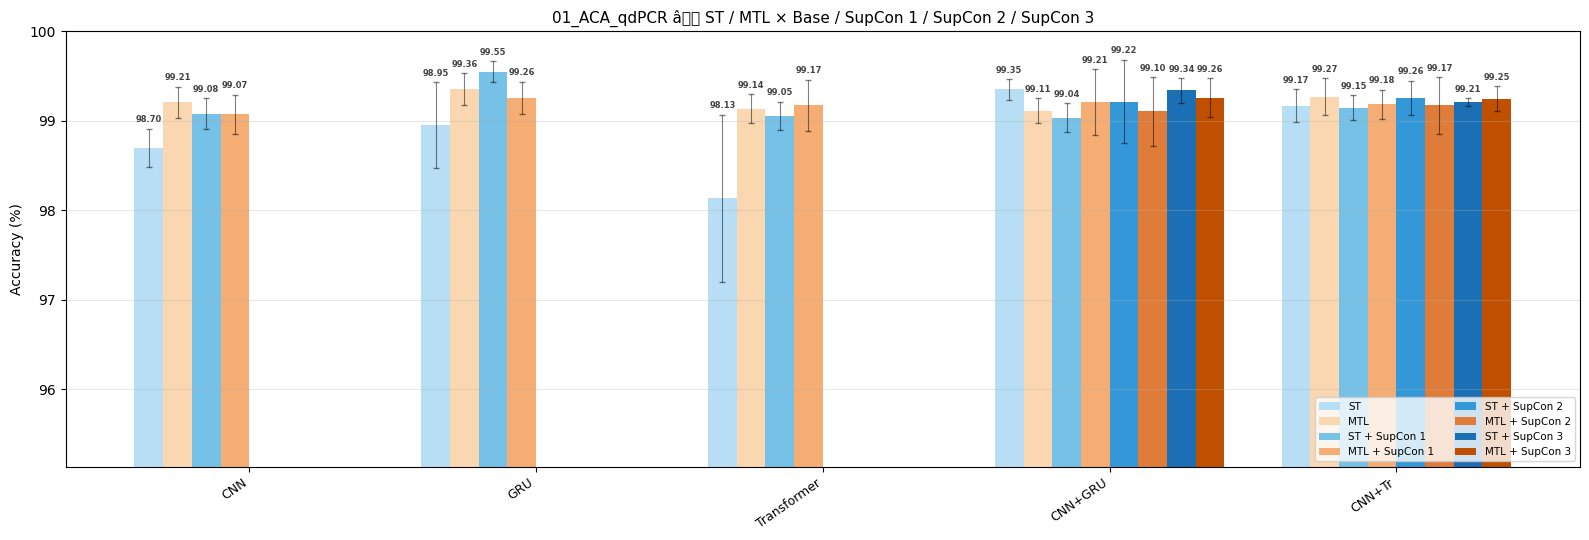

,ST (%),ST+SC1 (%),ST+SC2 (%),ST+SC3 (%),MTL (%),MTL+SC1 (%),MTL+SC2 (%),MTL+SC3 (%)
Model,,,,,,,,
CNN,98.70 ± 0.21,99.08 ± 0.17,â,â,99.21 ± 0.17,99.07 ± 0.22,â,â
GRU,98.95 ± 0.48,99.55 ± 0.12,â,â,99.36 ± 0.18,99.26 ± 0.18,â,â
Transformer,98.13 ± 0.93,99.05 ± 0.16,â,â,99.14 ± 0.16,99.17 ± 0.29,â,â
CNN+GRU,99.35 ± 0.12,99.04 ± 0.16,99.22 ± 0.47,99.34 ± 0.14,99.11 ± 0.14,99.21 ± 0.37,99.10 ± 0.38,99.26 ± 0.22
CNN+Tr,99.17 ± 0.18,99.15 ± 0.14,99.26 ± 0.19,99.21 ± 0.04,99.27 ± 0.20,99.18 ± 0.16,99.17 ± 0.32,99.25 ± 0.14


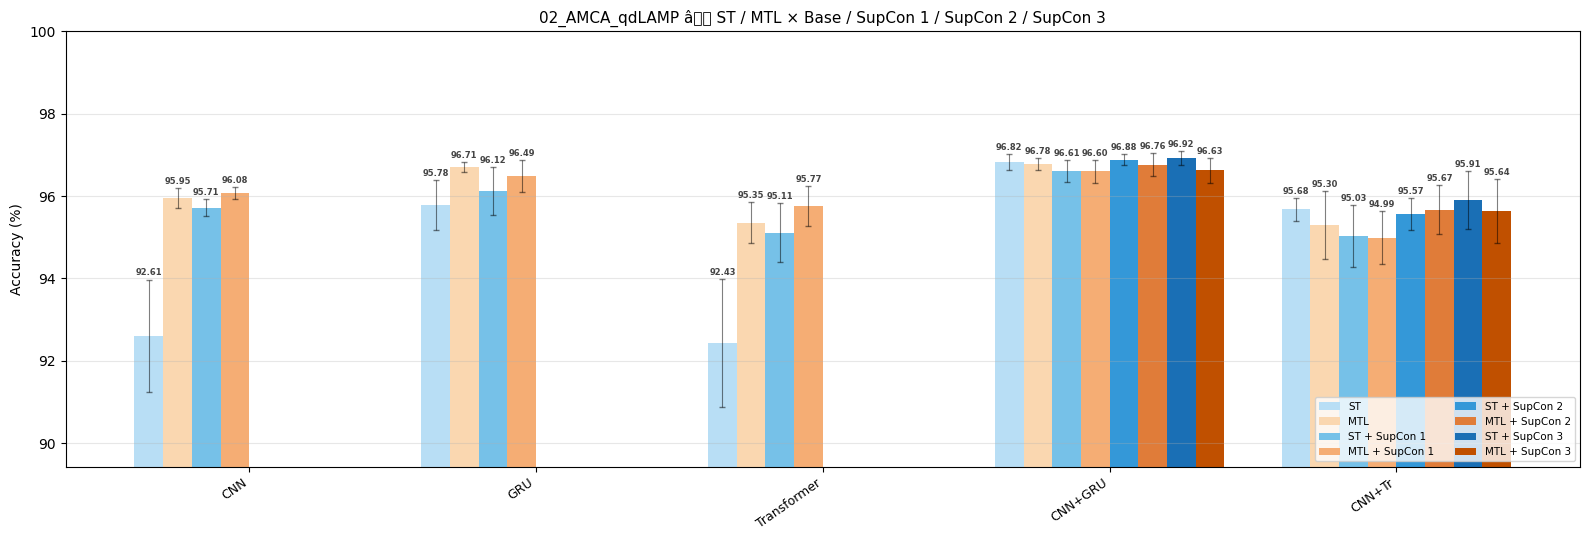

,ST (%),ST+SC1 (%),ST+SC2 (%),ST+SC3 (%),MTL (%),MTL+SC1 (%),MTL+SC2 (%),MTL+SC3 (%)
Model,,,,,,,,
CNN,92.61 ± 1.37,95.71 ± 0.20,â,â,95.95 ± 0.25,96.08 ± 0.14,â,â
GRU,95.78 ± 0.61,96.12 ± 0.58,â,â,96.71 ± 0.12,96.49 ± 0.38,â,â
Transformer,92.43 ± 1.56,95.11 ± 0.71,â,â,95.35 ± 0.49,95.77 ± 0.49,â,â
CNN+GRU,96.82 ± 0.20,96.61 ± 0.27,96.88 ± 0.14,96.92 ± 0.17,96.78 ± 0.15,96.60 ± 0.29,96.76 ± 0.27,96.63 ± 0.30
CNN+Tr,95.68 ± 0.28,95.03 ± 0.76,95.57 ± 0.39,95.91 ± 0.70,95.30 ± 0.82,94.99 ± 0.64,95.67 ± 0.59,95.64 ± 0.78


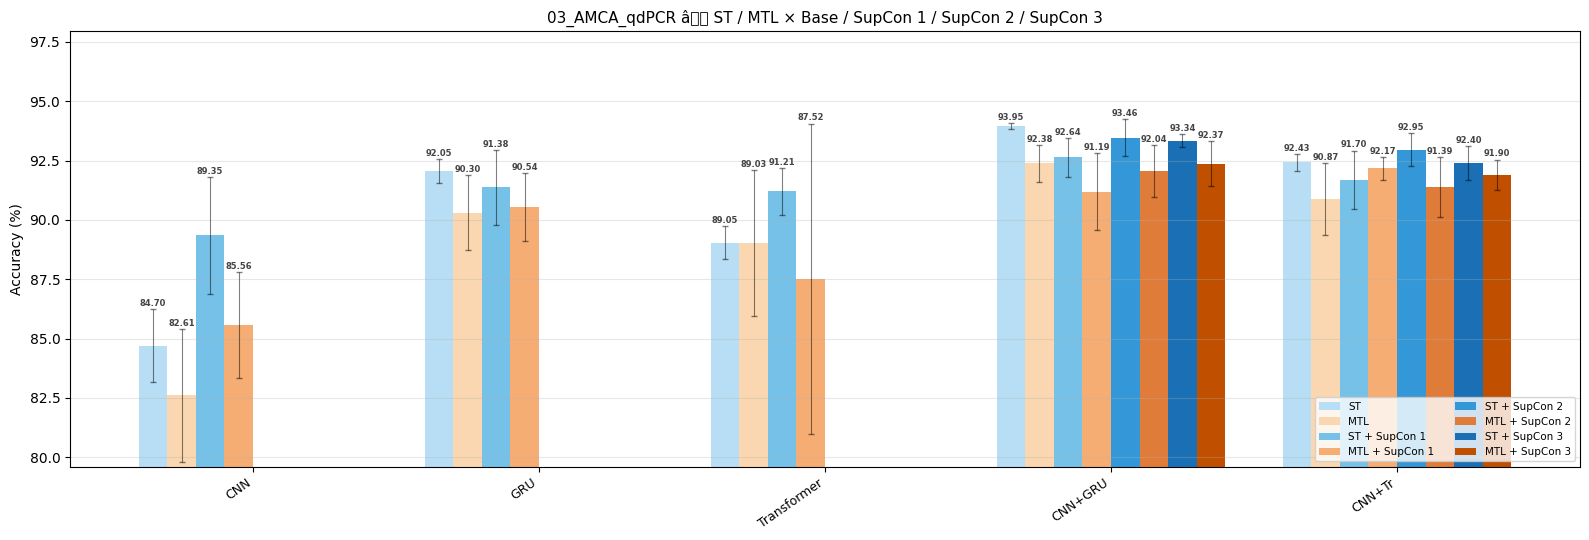

,ST (%),ST+SC1 (%),ST+SC2 (%),ST+SC3 (%),MTL (%),MTL+SC1 (%),MTL+SC2 (%),MTL+SC3 (%)
Model,,,,,,,,
CNN,84.70 ± 1.53,89.35 ± 2.46,â,â,82.61 ± 2.80,85.56 ± 2.23,â,â
GRU,92.05 ± 0.51,91.38 ± 1.57,â,â,90.30 ± 1.57,90.54 ± 1.42,â,â
Transformer,89.05 ± 0.70,91.21 ± 0.99,â,â,89.03 ± 3.09,87.52 ± 6.54,â,â
CNN+GRU,93.95 ± 0.12,92.64 ± 0.82,93.46 ± 0.78,93.34 ± 0.28,92.38 ± 0.77,91.19 ± 1.64,92.04 ± 1.10,92.37 ± 0.96
CNN+Tr,92.43 ± 0.35,91.70 ± 1.22,92.95 ± 0.69,92.40 ± 0.70,90.87 ± 1.51,92.17 ± 0.49,91.39 ± 1.27,91.90 ± 0.64


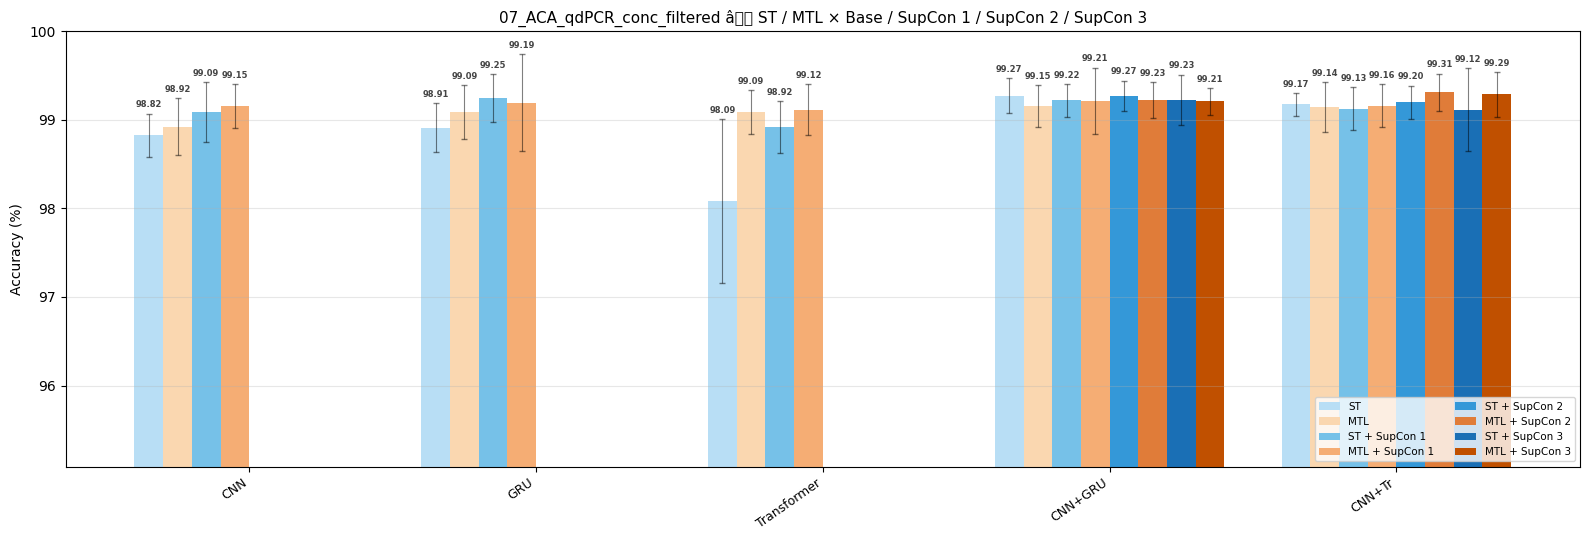

,ST (%),ST+SC1 (%),ST+SC2 (%),ST+SC3 (%),MTL (%),MTL+SC1 (%),MTL+SC2 (%),MTL+SC3 (%)
Model,,,,,,,,
CNN,98.82 ± 0.24,99.09 ± 0.34,â,â,98.92 ± 0.32,99.15 ± 0.25,â,â
GRU,98.91 ± 0.27,99.25 ± 0.27,â,â,99.09 ± 0.30,99.19 ± 0.55,â,â
Transformer,98.09 ± 0.92,98.92 ± 0.29,â,â,99.09 ± 0.25,99.12 ± 0.29,â,â
CNN+GRU,99.27 ± 0.20,99.22 ± 0.18,99.27 ± 0.17,99.23 ± 0.28,99.15 ± 0.24,99.21 ± 0.38,99.23 ± 0.20,99.21 ± 0.15
CNN+Tr,99.17 ± 0.13,99.13 ± 0.24,99.20 ± 0.19,99.12 ± 0.47,99.14 ± 0.28,99.16 ± 0.24,99.31 ± 0.21,99.29 ± 0.25


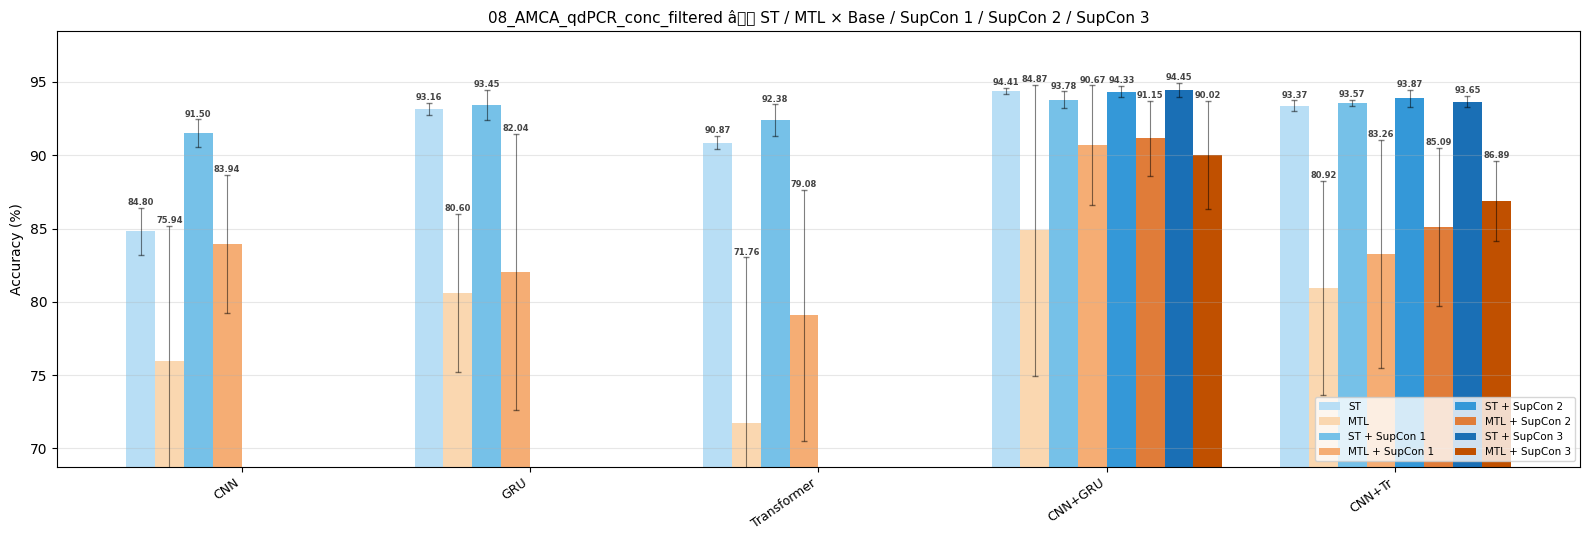

,ST (%),ST+SC1 (%),ST+SC2 (%),ST+SC3 (%),MTL (%),MTL+SC1 (%),MTL+SC2 (%),MTL+SC3 (%)
Model,,,,,,,,
CNN,84.80 ± 1.60,91.50 ± 0.95,â,â,75.94 ± 9.26,83.94 ± 4.70,â,â
GRU,93.16 ± 0.41,93.45 ± 1.03,â,â,80.60 ± 5.38,82.04 ± 9.42,â,â
Transformer,90.87 ± 0.45,92.38 ± 1.09,â,â,71.76 ± 11.27,79.08 ± 8.56,â,â
CNN+GRU,94.41 ± 0.21,93.78 ± 0.57,94.33 ± 0.39,94.45 ± 0.47,84.87 ± 9.92,90.67 ± 4.10,91.15 ± 2.57,90.02 ± 3.69
CNN+Tr,93.37 ± 0.36,93.57 ± 0.22,93.87 ± 0.57,93.65 ± 0.38,80.92 ± 7.31,83.26 ± 7.80,85.09 ± 5.40,86.89 ± 2.75


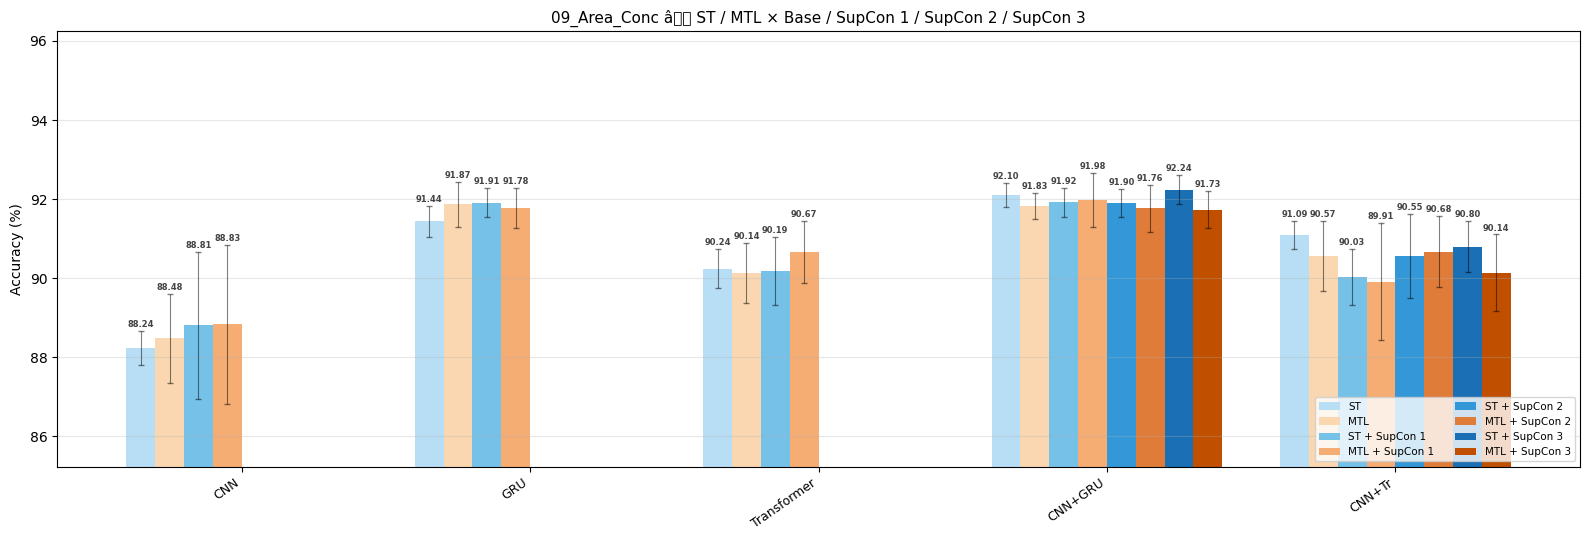

,ST (%),ST+SC1 (%),ST+SC2 (%),ST+SC3 (%),MTL (%),MTL+SC1 (%),MTL+SC2 (%),MTL+SC3 (%)
Model,,,,,,,,
CNN,88.24 ± 0.43,88.81 ± 1.86,â,â,88.48 ± 1.12,88.83 ± 2.00,â,â
GRU,91.44 ± 0.39,91.91 ± 0.37,â,â,91.87 ± 0.57,91.78 ± 0.51,â,â
Transformer,90.24 ± 0.50,90.19 ± 0.85,â,â,90.14 ± 0.76,90.67 ± 0.79,â,â
CNN+GRU,92.10 ± 0.31,91.92 ± 0.37,91.90 ± 0.37,92.24 ± 0.37,91.83 ± 0.34,91.98 ± 0.69,91.76 ± 0.59,91.73 ± 0.47
CNN+Tr,91.09 ± 0.36,90.03 ± 0.70,90.55 ± 1.06,90.80 ± 0.64,90.57 ± 0.88,89.91 ± 1.48,90.68 ± 0.89,90.14 ± 0.96


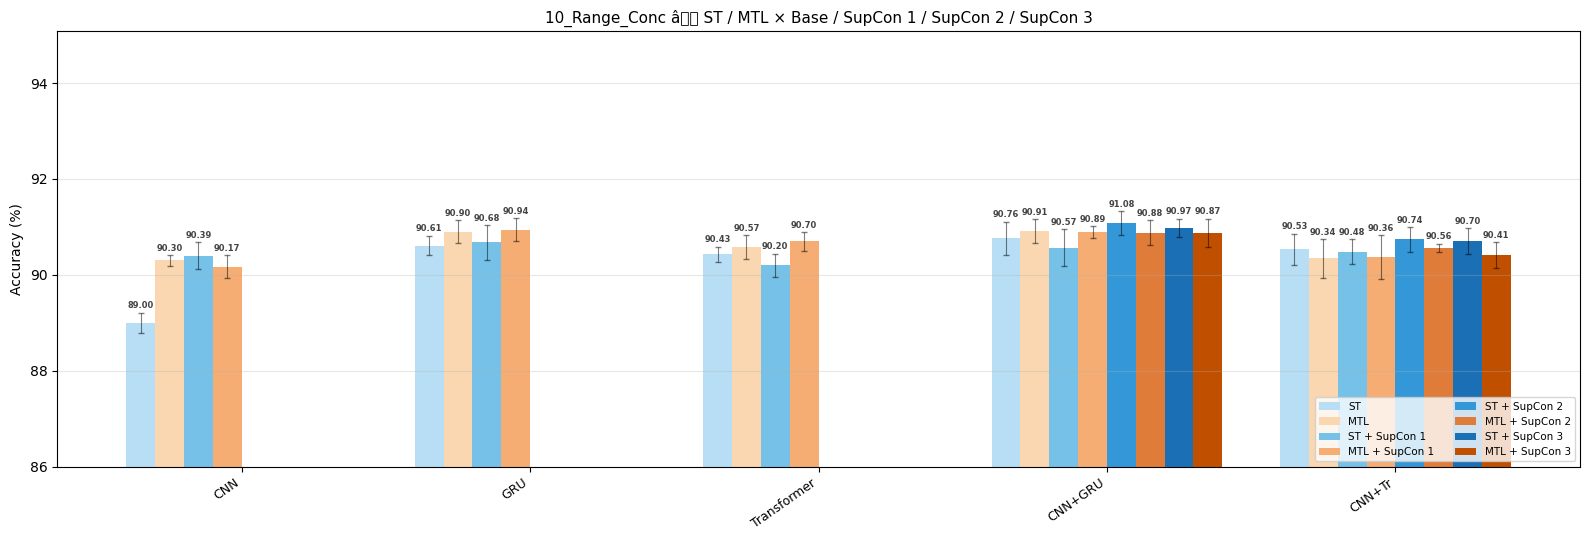

,ST (%),ST+SC1 (%),ST+SC2 (%),ST+SC3 (%),MTL (%),MTL+SC1 (%),MTL+SC2 (%),MTL+SC3 (%)
Model,,,,,,,,
CNN,89.00 ± 0.21,90.39 ± 0.28,â,â,90.30 ± 0.12,90.17 ± 0.24,â,â
GRU,90.61 ± 0.20,90.68 ± 0.36,â,â,90.90 ± 0.23,90.94 ± 0.24,â,â
Transformer,90.43 ± 0.16,90.20 ± 0.24,â,â,90.57 ± 0.25,90.70 ± 0.20,â,â
CNN+GRU,90.76 ± 0.35,90.57 ± 0.39,91.08 ± 0.25,90.97 ± 0.19,90.91 ± 0.25,90.89 ± 0.13,90.88 ± 0.25,90.87 ± 0.30
CNN+Tr,90.53 ± 0.33,90.48 ± 0.26,90.74 ± 0.26,90.70 ± 0.27,90.34 ± 0.40,90.36 ± 0.46,90.56 ± 0.09,90.41 ± 0.27


In [102]:
_folders = (
    [FOLDER] if FOLDER is not None
    else sorted(f.name for f in Path(LAB_FOLDER).iterdir()
                if f.is_dir() and (f / RESULT_JL).exists())
)
_folders = ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered', '09_Area_Conc', '10_Range_Conc']

for _folder in _folders:
    _raw = load_results(_folder)
    if _raw is None:
        continue
    _res, _, _ = _get_res_entry(_raw, OUTLIER_FILTER)
    if _res is None:
        print(f'[!] {_folder}: no entry for filter={OUTLIER_FILTER!r}. Skipping.')
        continue

    reg_data = collect_reg_results(_res)

    plot_stmtl_comparison(_res, _folder)
    # plot_reg_metrics(reg_data, _folder)
    # plot_reg_scatter(reg_data, _folder)
    # plot_reg_residuals(reg_data, _folder)

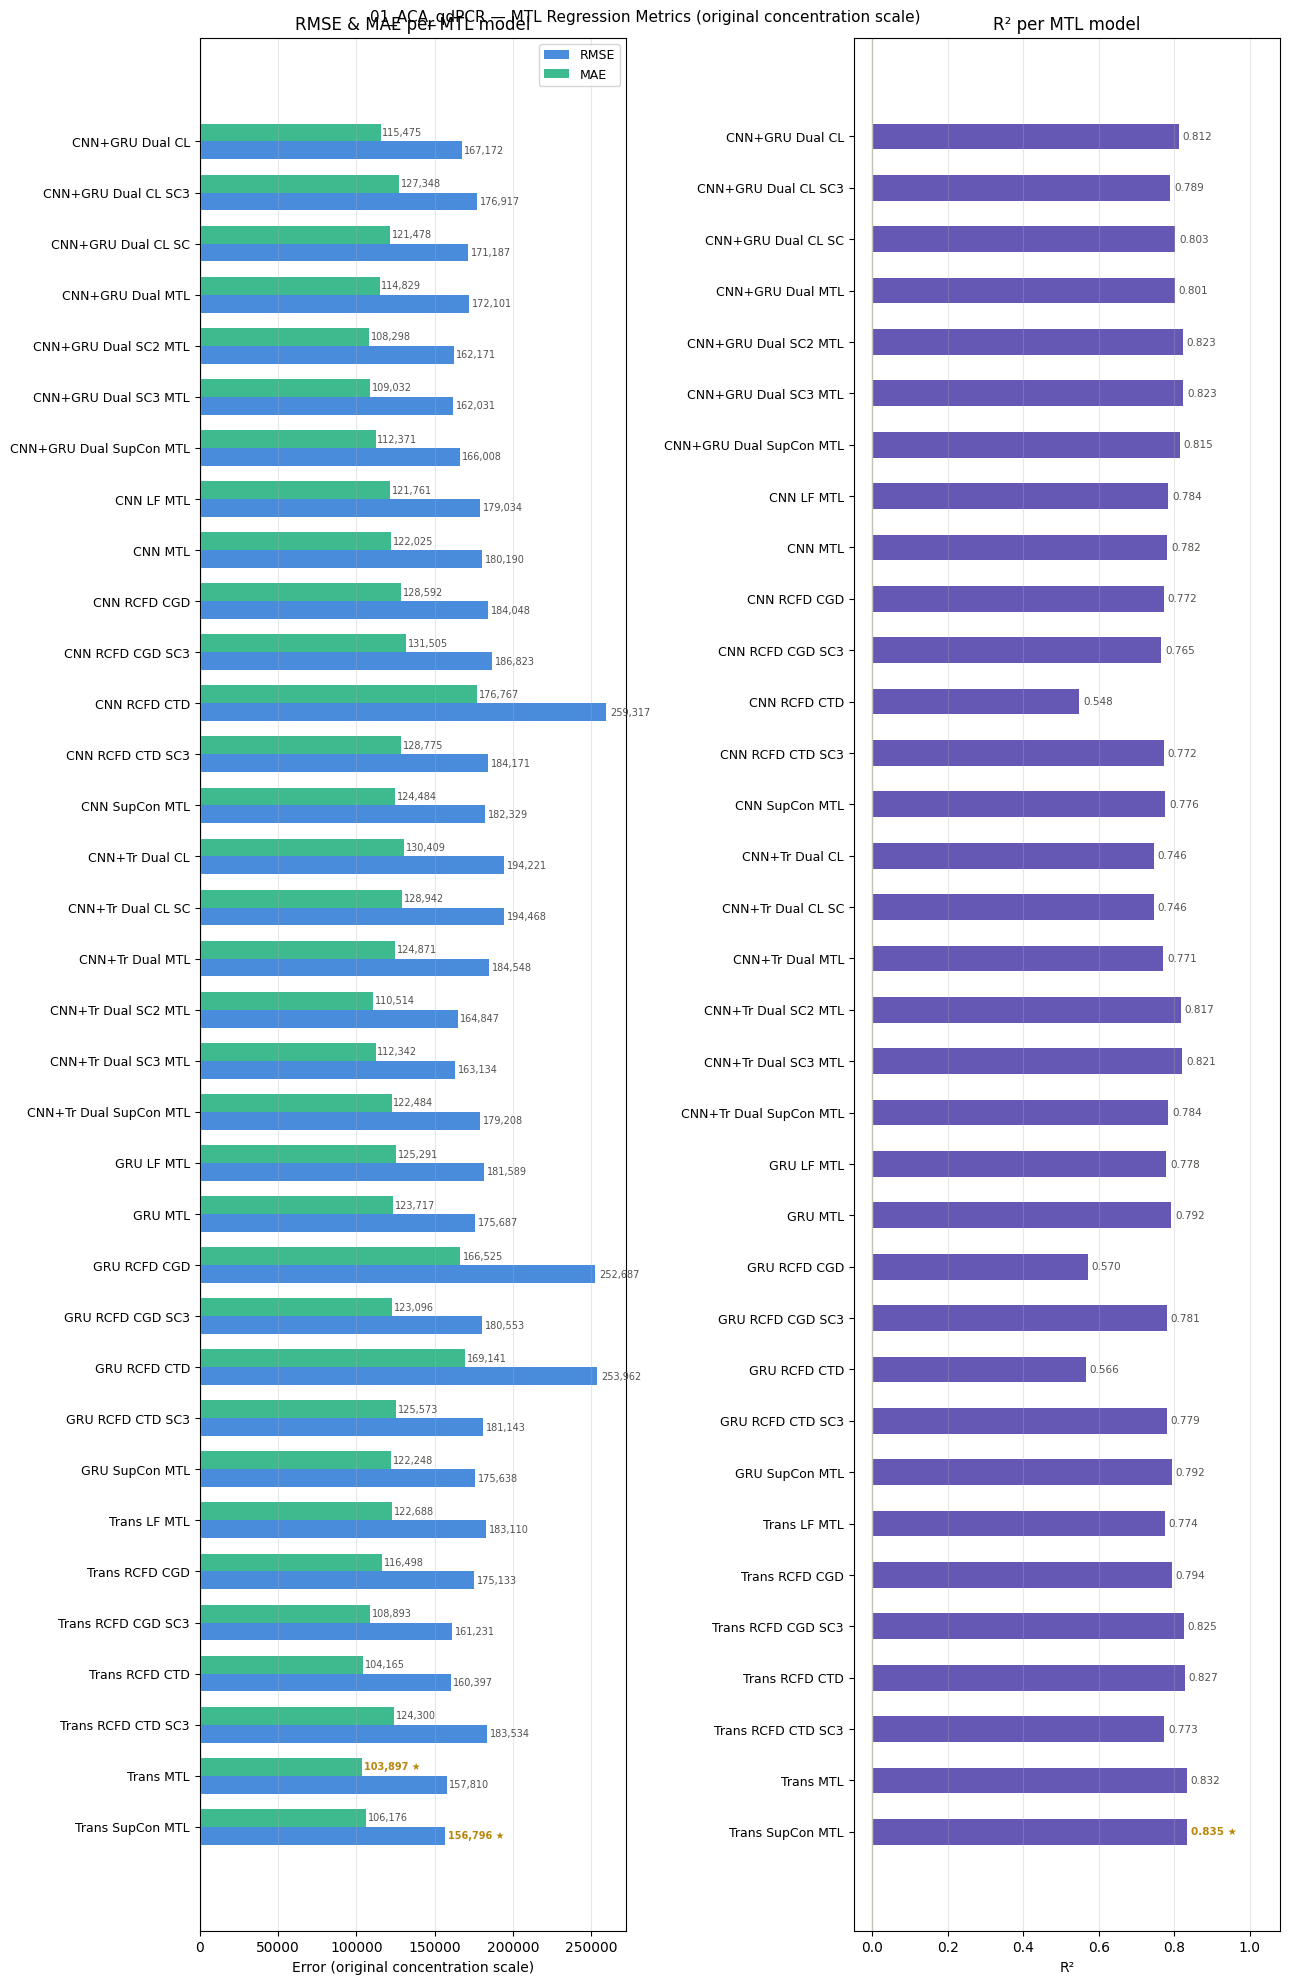

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual CL,"167,171.78","115,474.59",0.8120,16188
CNN+GRU Dual CL SC3,"176,916.75","127,348.26",0.7894,16188
CNN+GRU Dual CL SC,"171,186.79","121,477.78",0.8029,16188
CNN+GRU Dual MTL,"172,101.46","114,828.77",0.8007,16188
CNN+GRU Dual SC2 MTL,"162,170.58","108,297.70",0.8231,16188
CNN+GRU Dual SC3 MTL,"162,031.10","109,032.24",0.8234,16188
CNN+GRU Dual SupCon MTL,"166,007.82","112,371.06",0.8146,16188
CNN LF MTL,"179,033.61","121,760.70",0.7844,16188
CNN MTL,"180,189.78","122,025.31",0.7816,16188


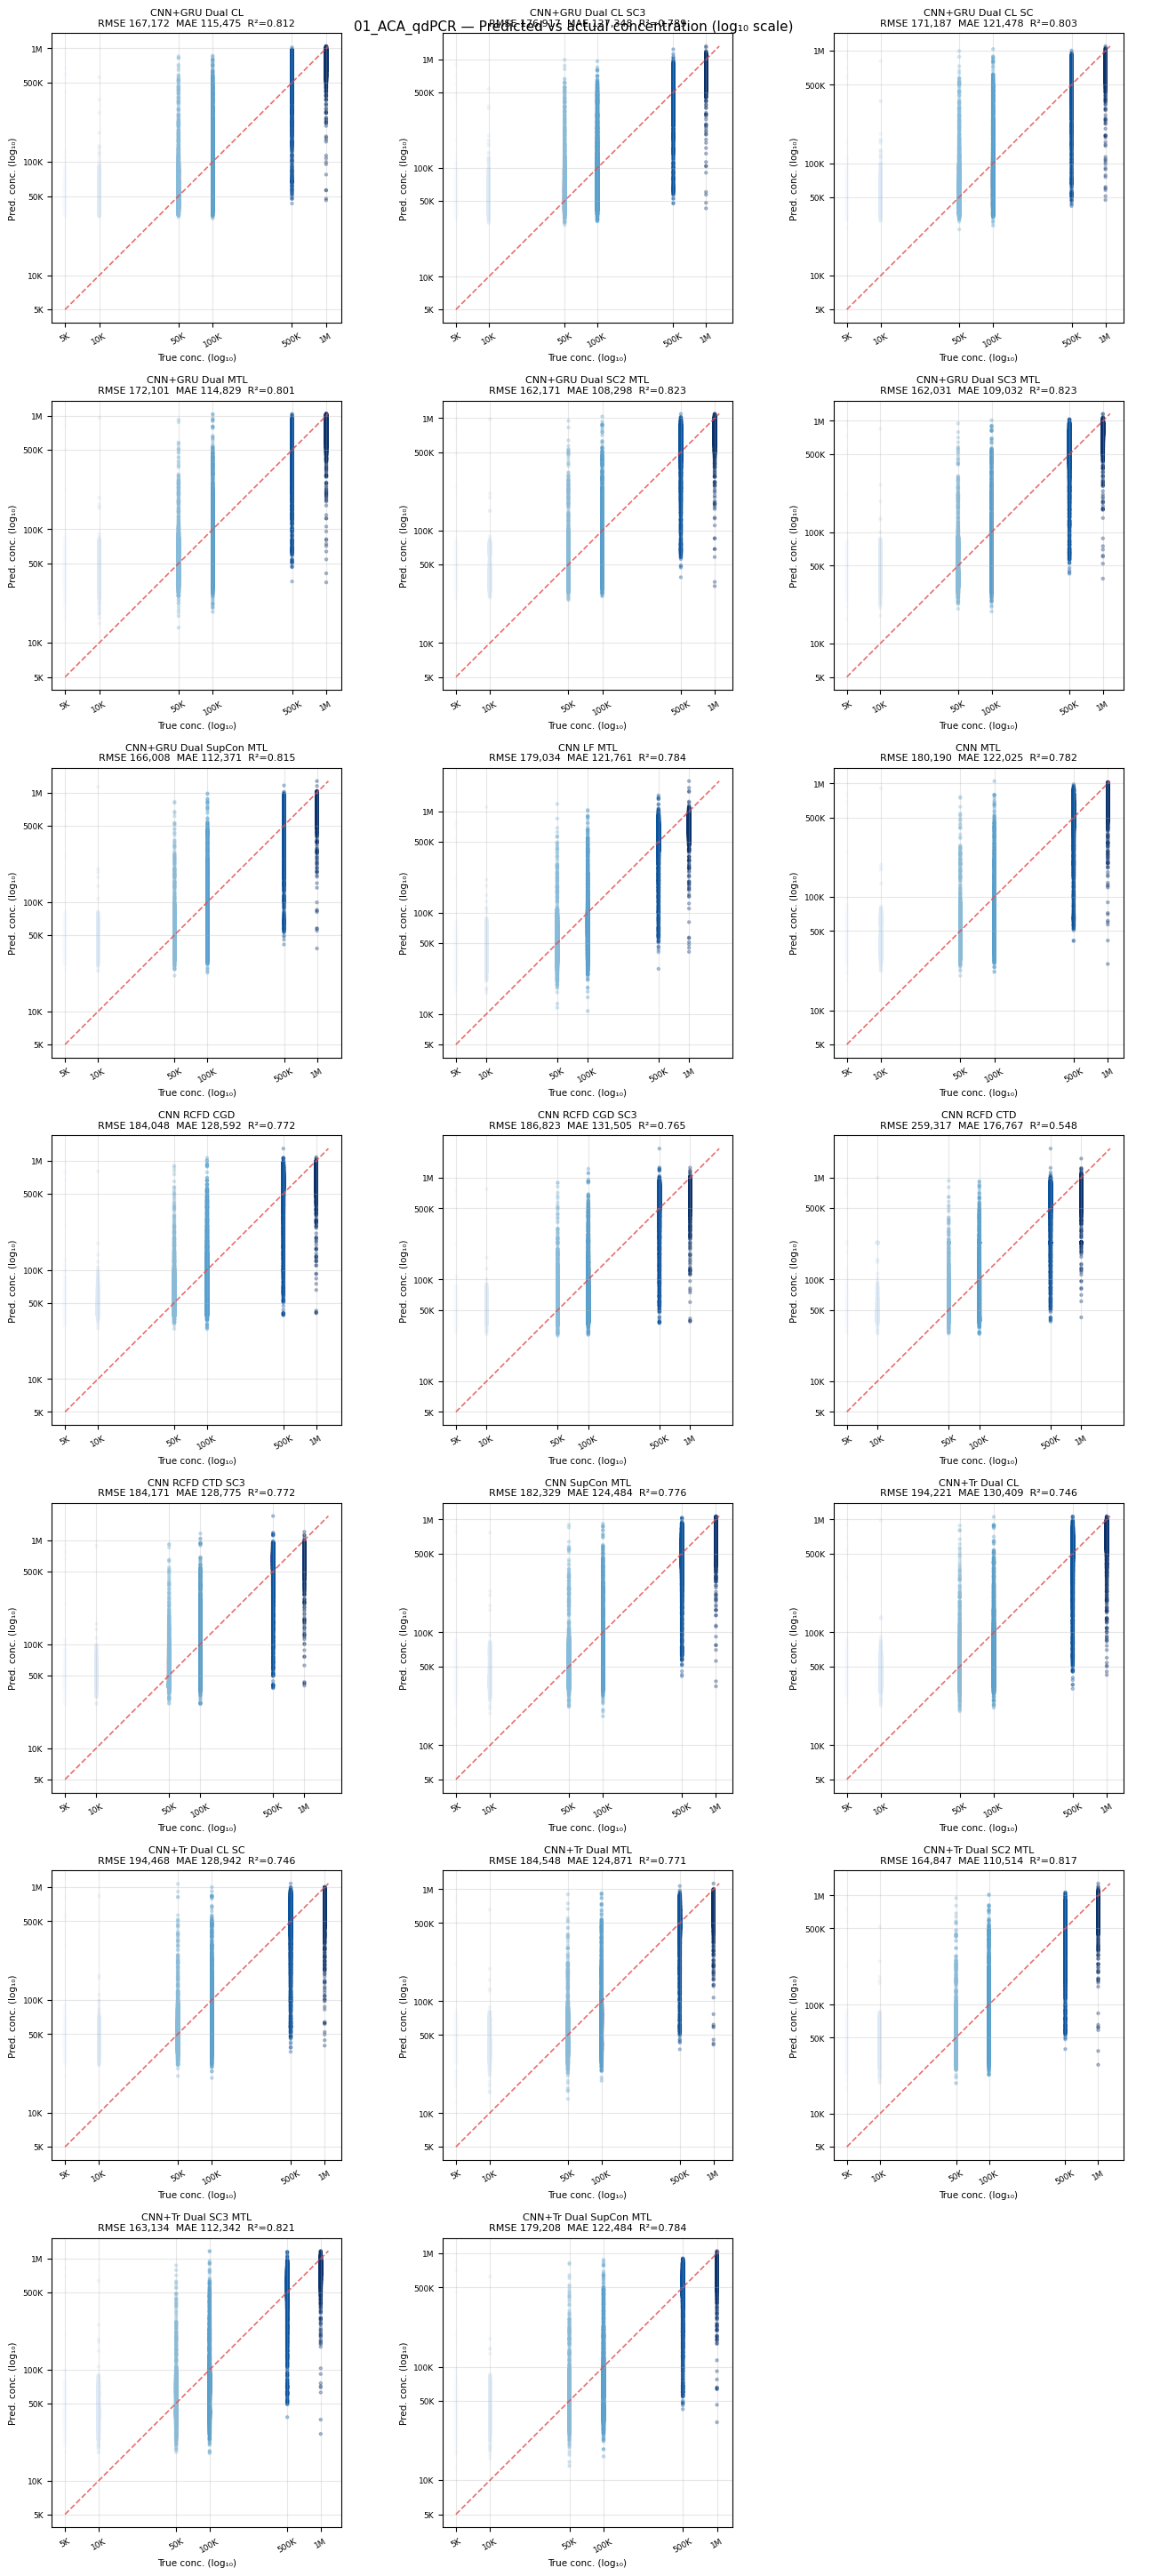

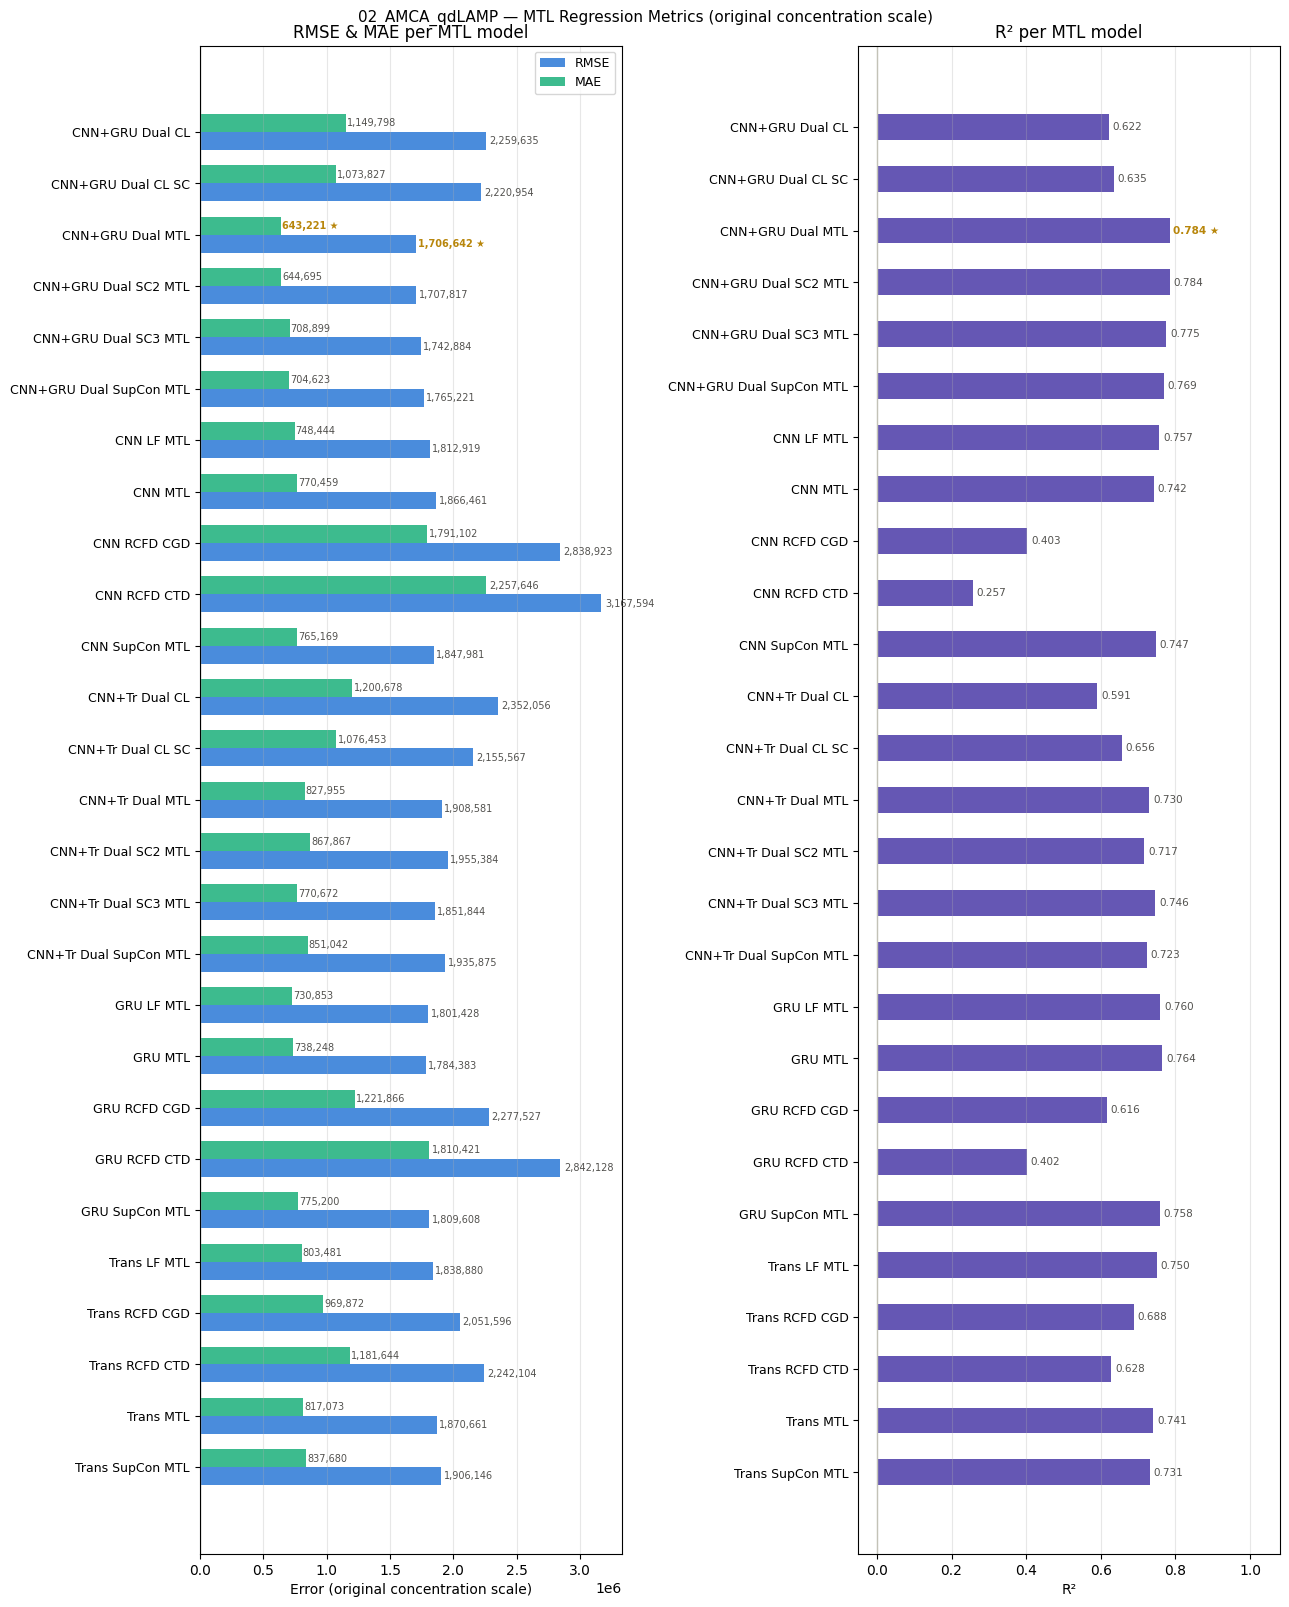

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual CL,"2,259,635.44","1,149,797.72",0.6221,54186
CNN+GRU Dual CL SC,"2,220,954.00","1,073,826.69",0.6349,54186
CNN+GRU Dual MTL,"1,706,642.26","643,220.76",0.7844,54186
CNN+GRU Dual SC2 MTL,"1,707,817.33","644,694.99",0.7841,54186
CNN+GRU Dual SC3 MTL,"1,742,883.74","708,898.72",0.7752,54186
CNN+GRU Dual SupCon MTL,"1,765,221.36","704,622.82",0.7694,54186
CNN LF MTL,"1,812,918.69","748,444.02",0.7567,54186
CNN MTL,"1,866,461.37","770,458.99",0.7422,54186
CNN RCFD CGD,"2,838,922.87","1,791,101.74",0.4035,54186


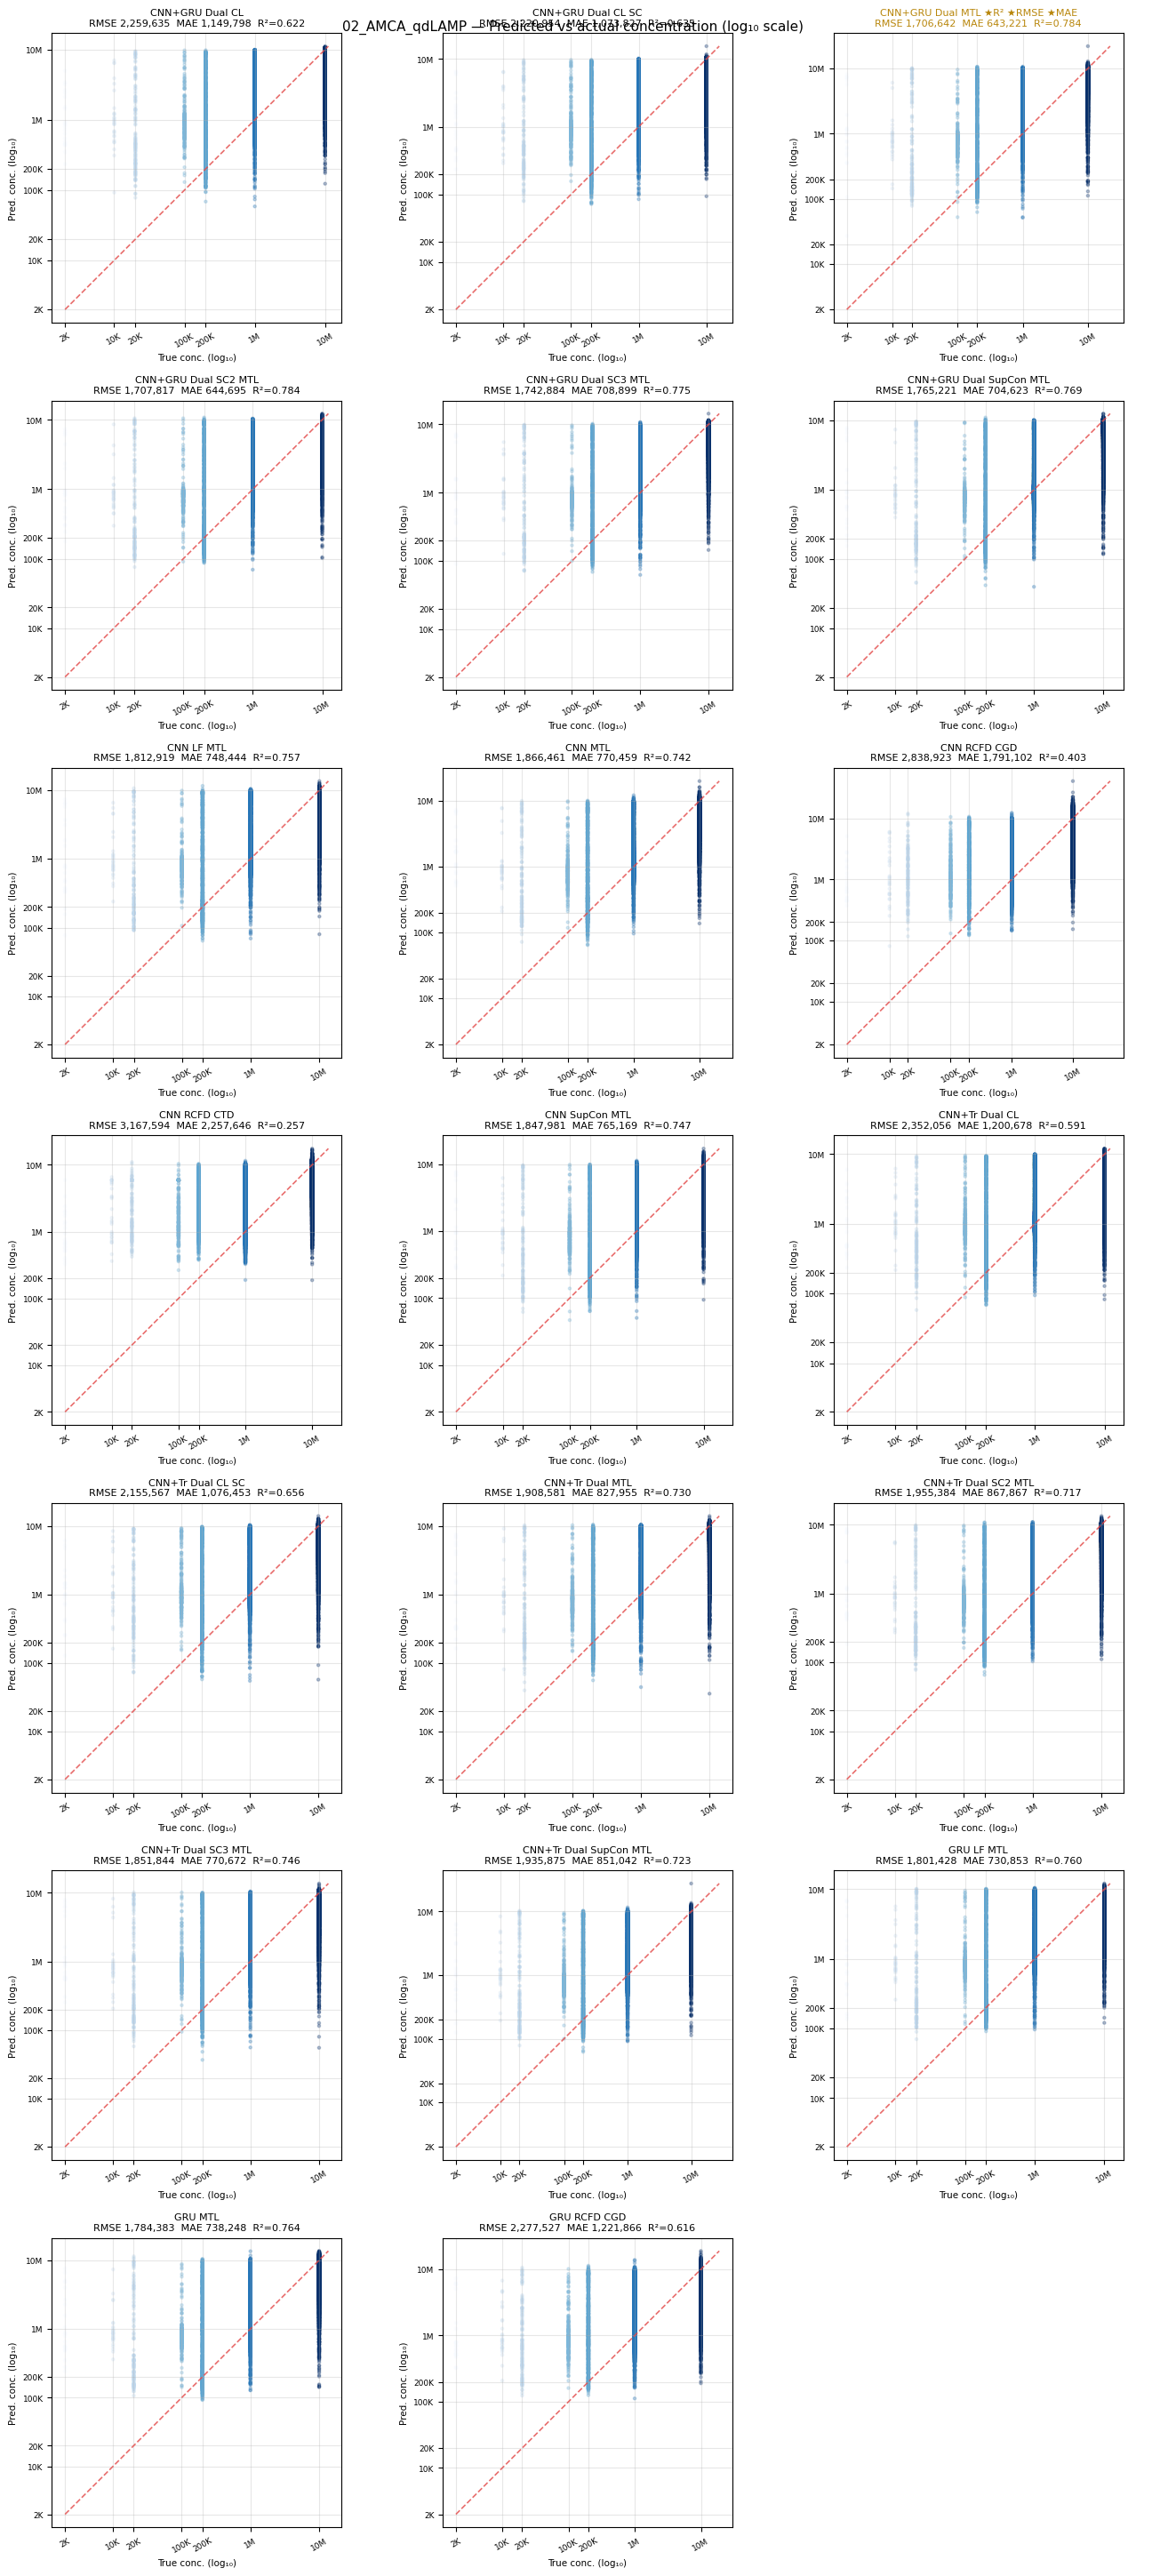

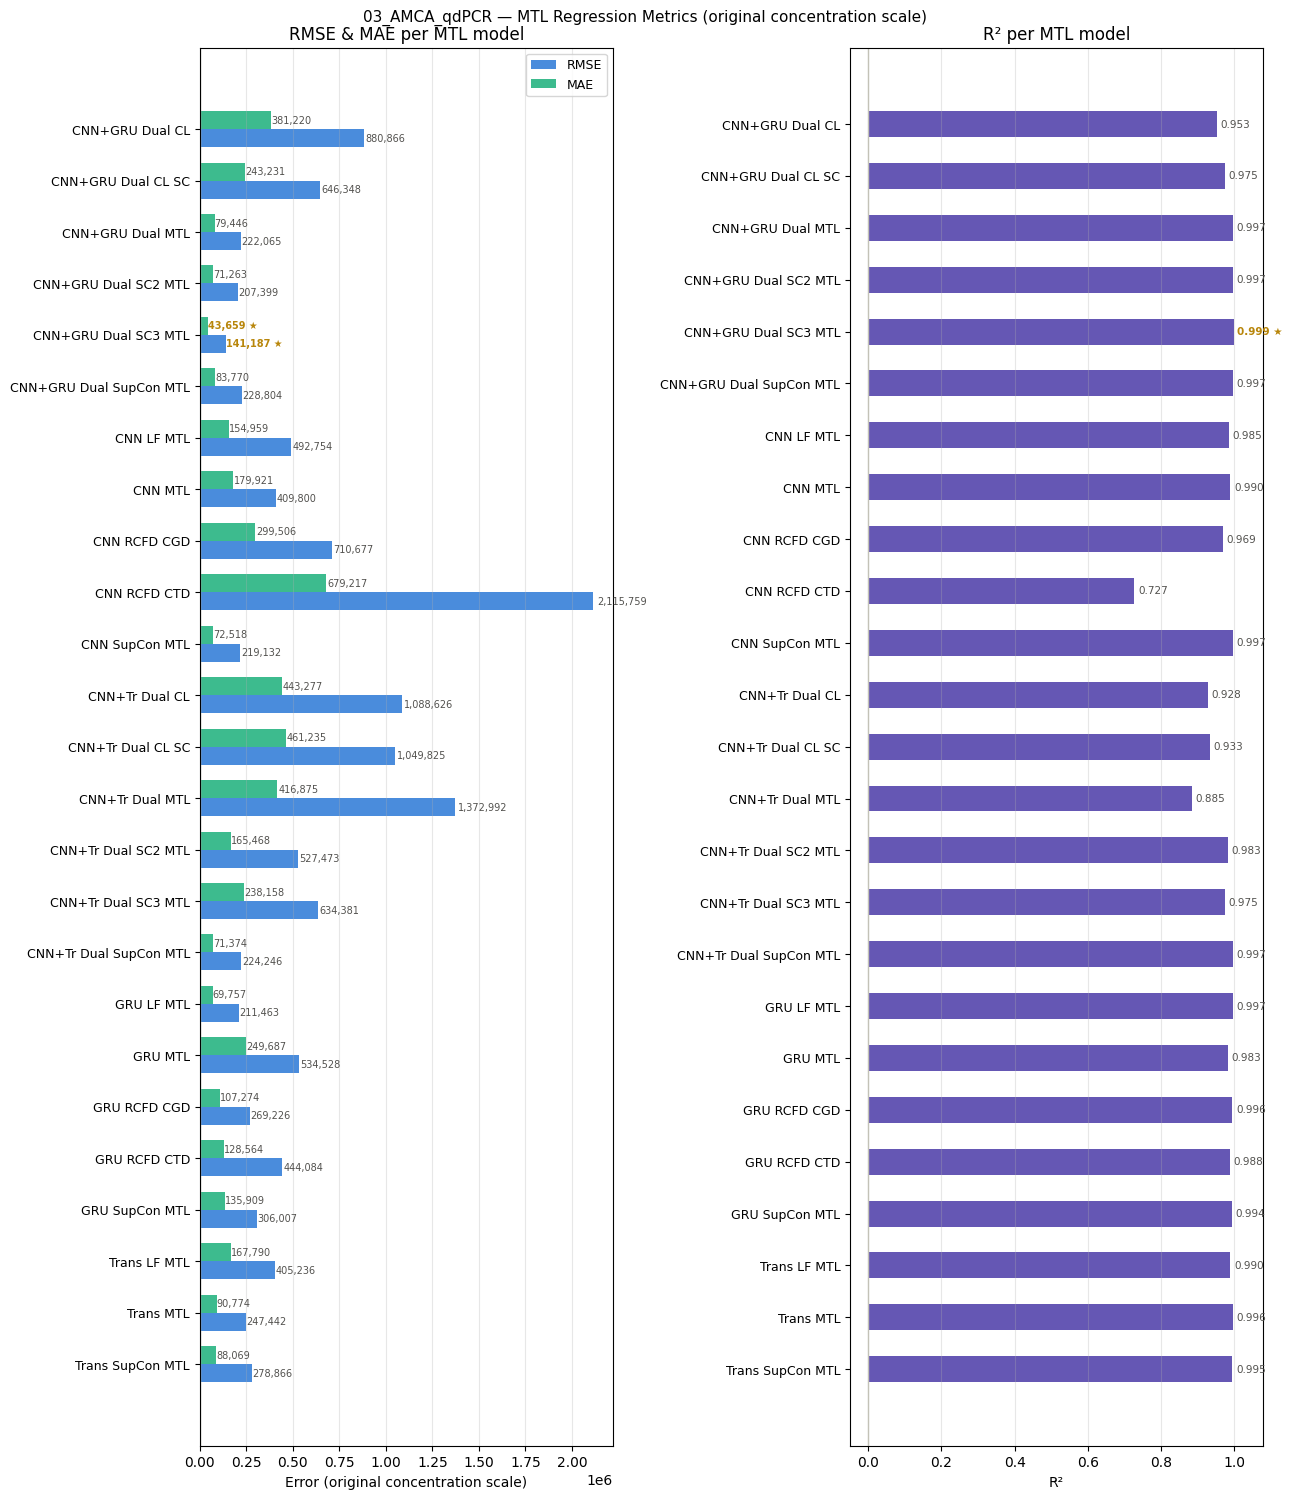

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual CL,"880,866.10","381,220.16",0.9527,58598
CNN+GRU Dual CL SC,"646,347.83","243,230.96",0.9746,58598
CNN+GRU Dual MTL,"222,065.40","79,445.95",0.9970,58598
CNN+GRU Dual SC2 MTL,"207,399.29","71,263.10",0.9974,58598
CNN+GRU Dual SC3 MTL,"141,186.54","43,659.06",0.9988,58598
CNN+GRU Dual SupCon MTL,"228,803.82","83,770.20",0.9968,58598
CNN LF MTL,"492,753.58","154,959.21",0.9852,58598
CNN MTL,"409,800.27","179,921.24",0.9898,58598
CNN RCFD CGD,"710,677.03","299,505.71",0.9692,58598


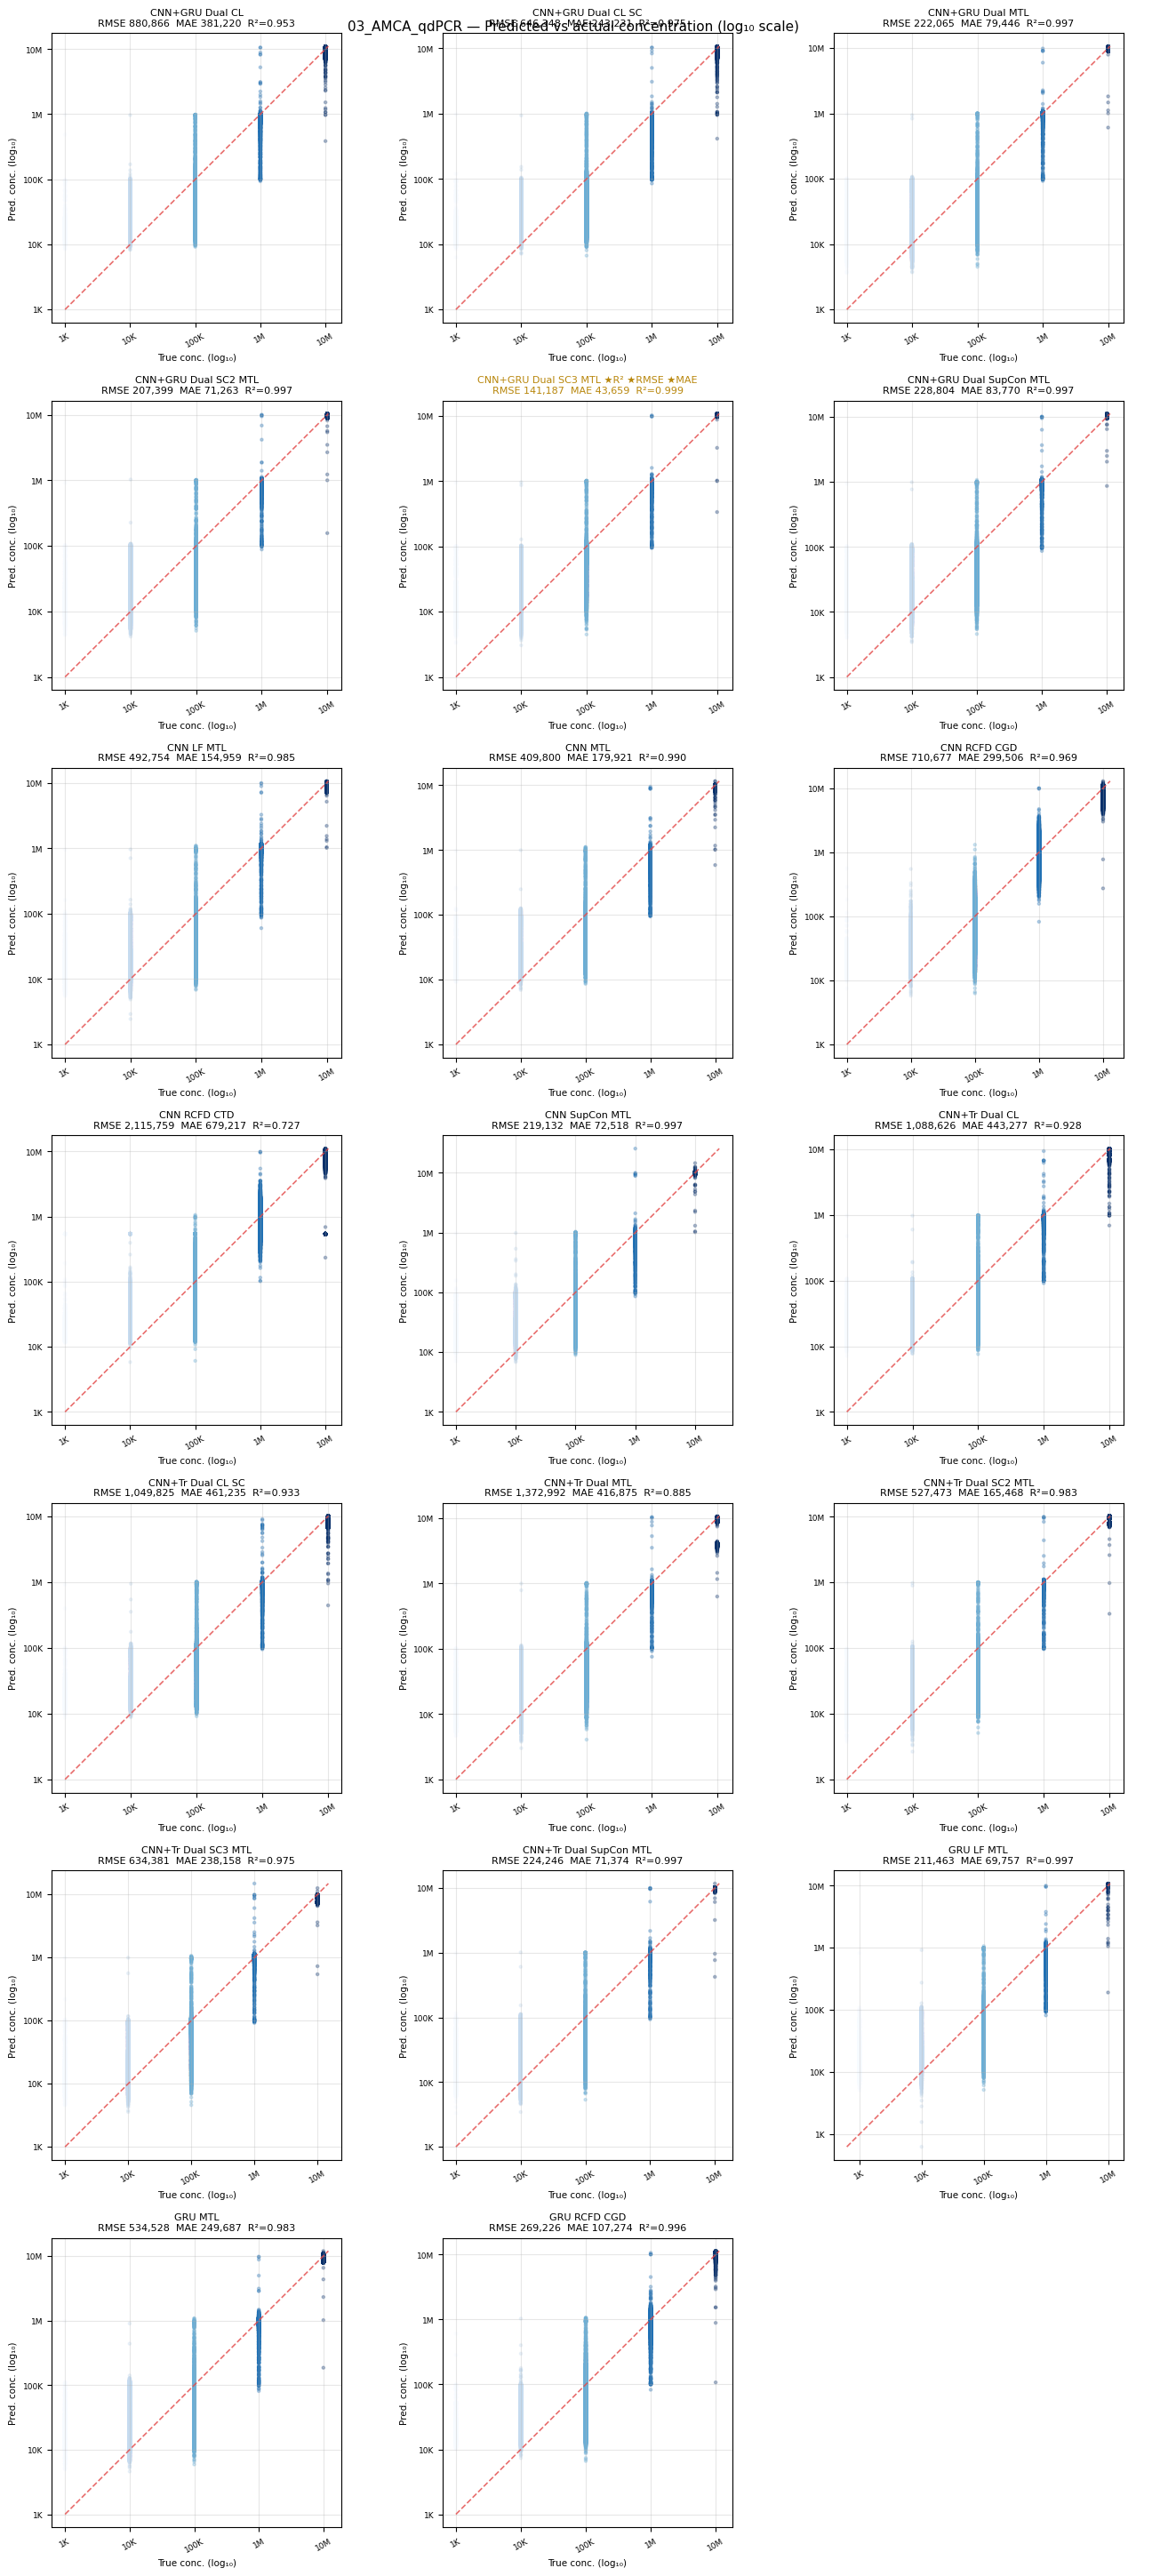

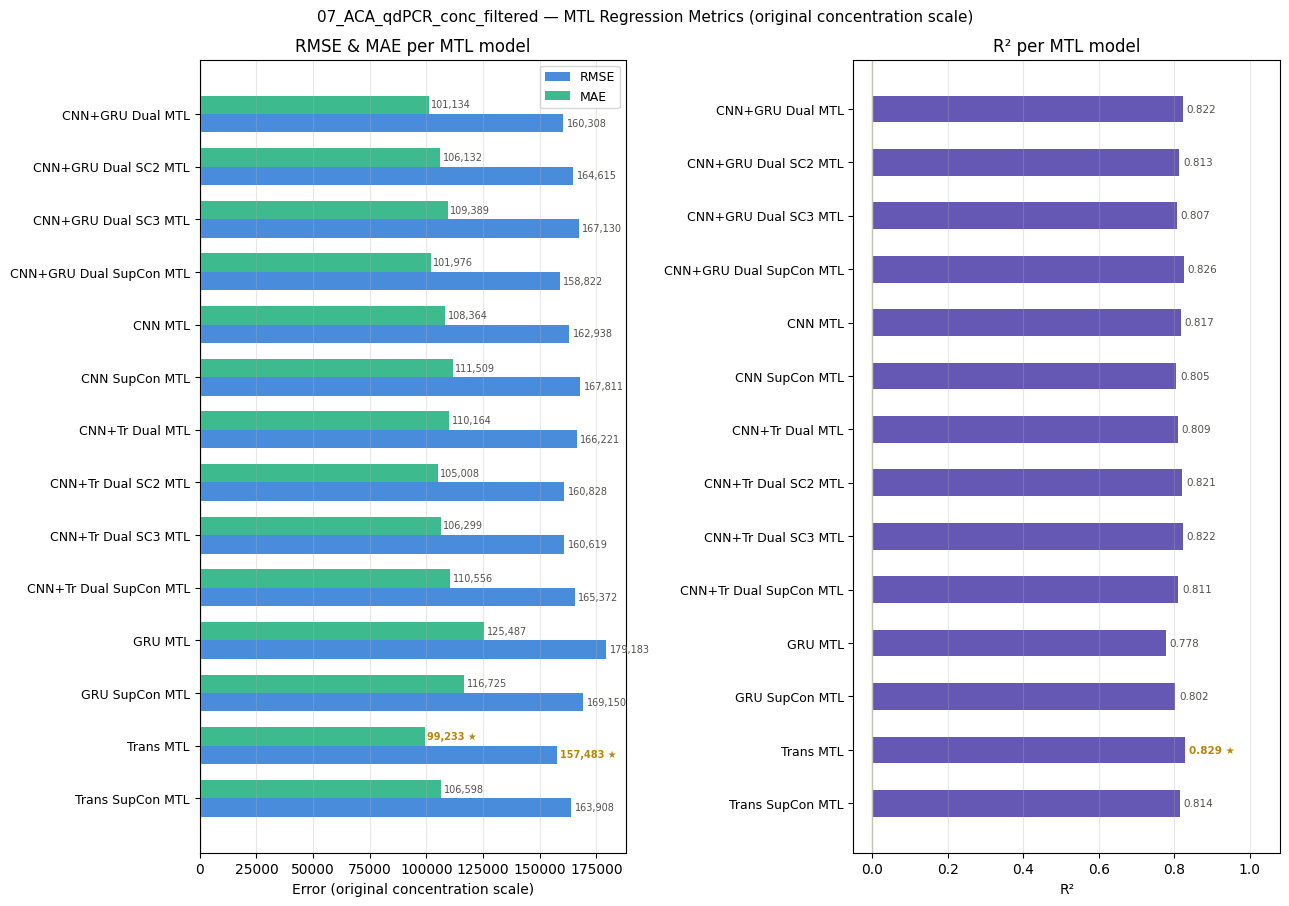

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual MTL,"160,307.63","101,133.60",0.8224,15146
CNN+GRU Dual SC2 MTL,"164,614.75","106,131.64",0.8127,15146
CNN+GRU Dual SC3 MTL,"167,130.21","109,388.54",0.8070,15146
CNN+GRU Dual SupCon MTL,"158,822.18","101,975.71",0.8257,15146
CNN MTL,"162,938.23","108,363.96",0.8165,15146
CNN SupCon MTL,"167,810.80","111,508.82",0.8054,15146
CNN+Tr Dual MTL,"166,221.33","110,163.76",0.8091,15146
CNN+Tr Dual SC2 MTL,"160,828.39","105,008.11",0.8213,15146
CNN+Tr Dual SC3 MTL,"160,618.51","106,299.44",0.8217,15146


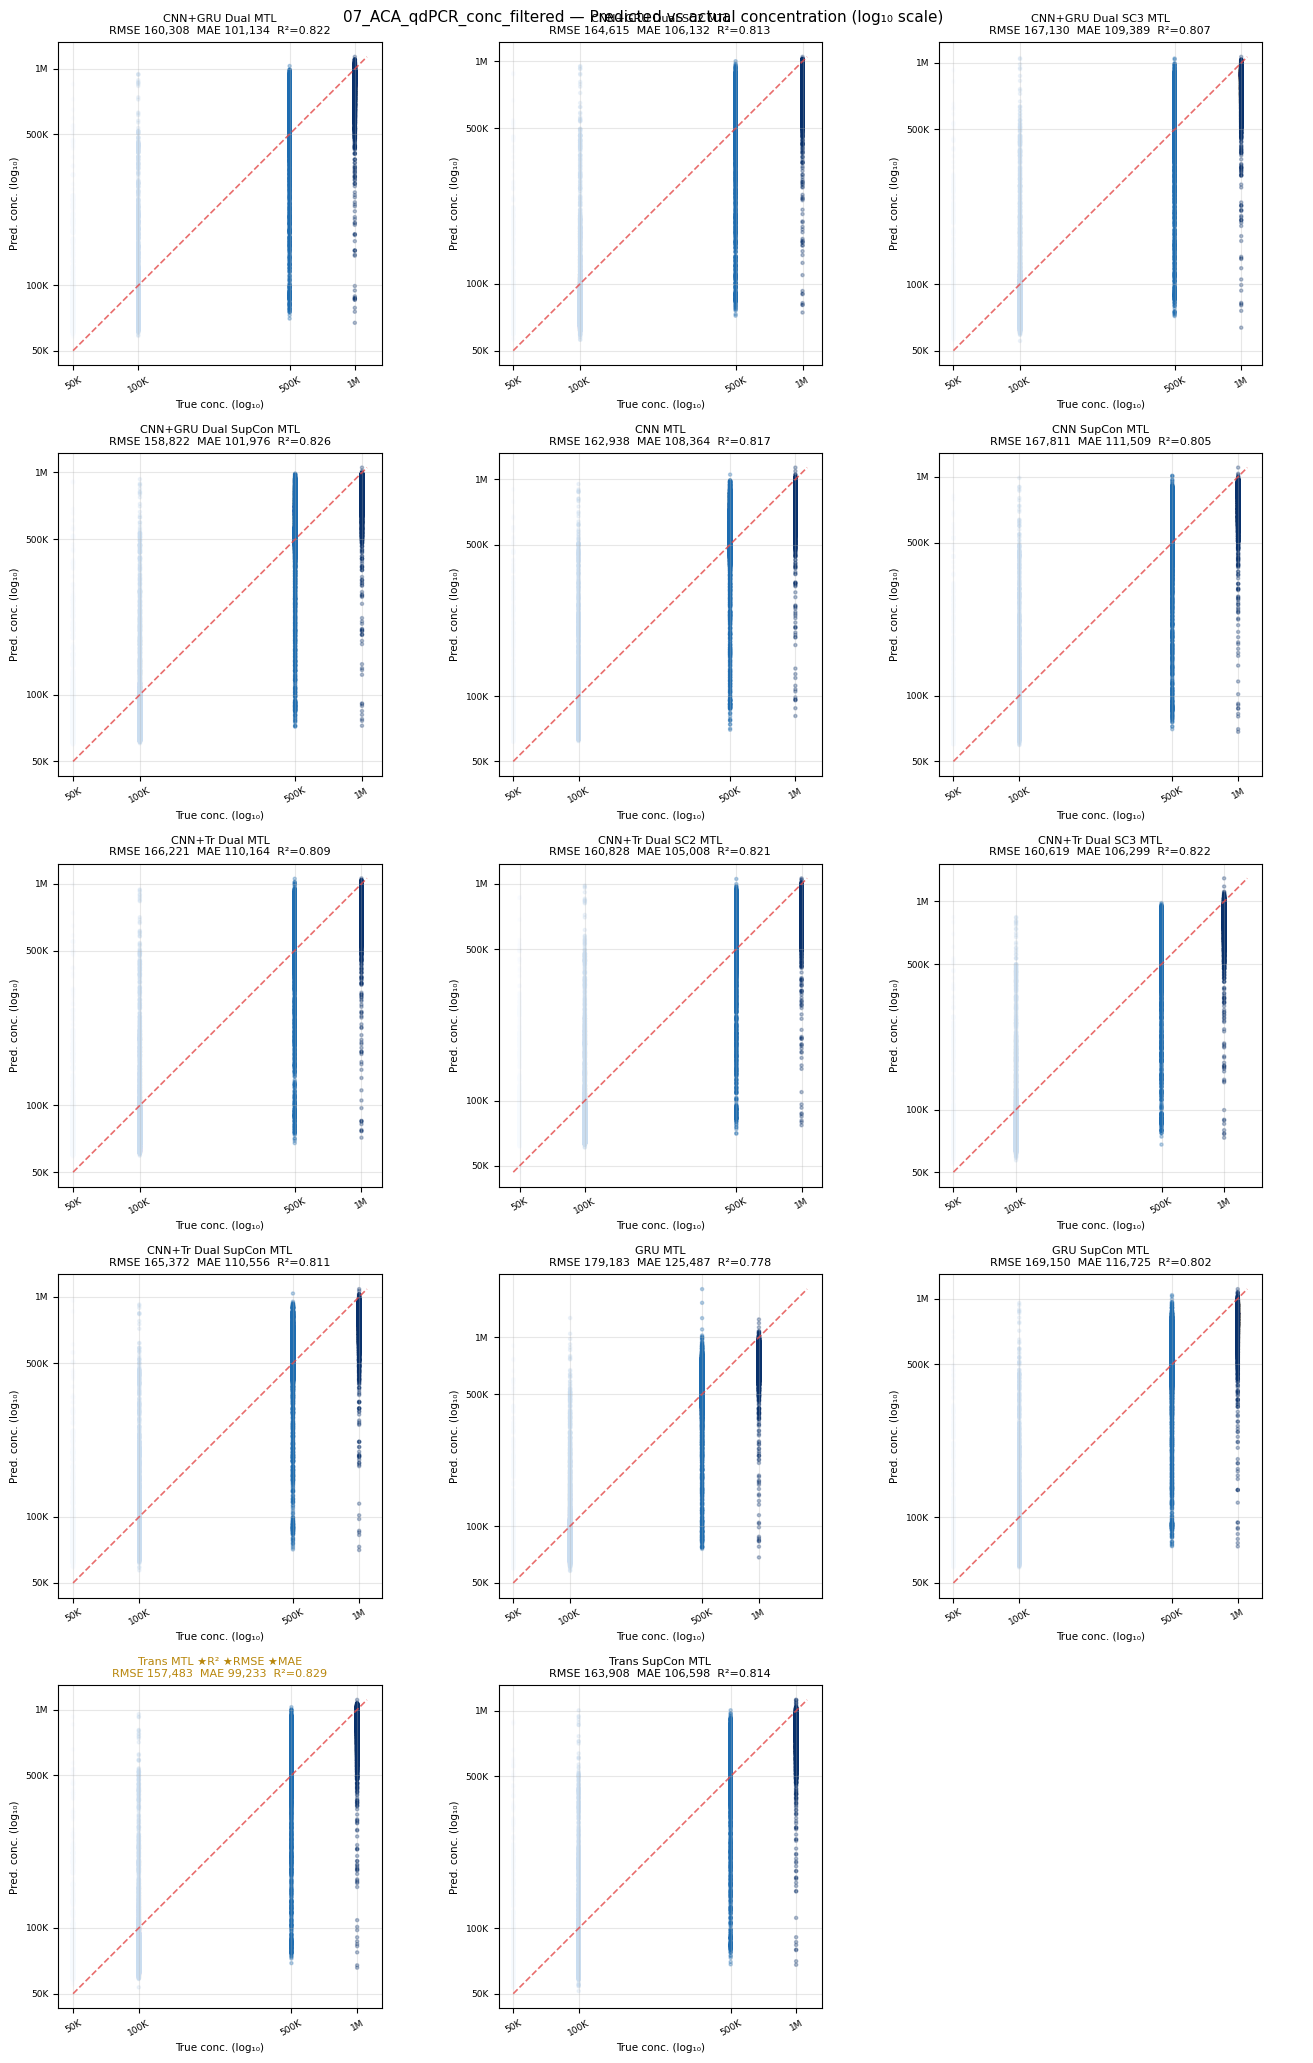

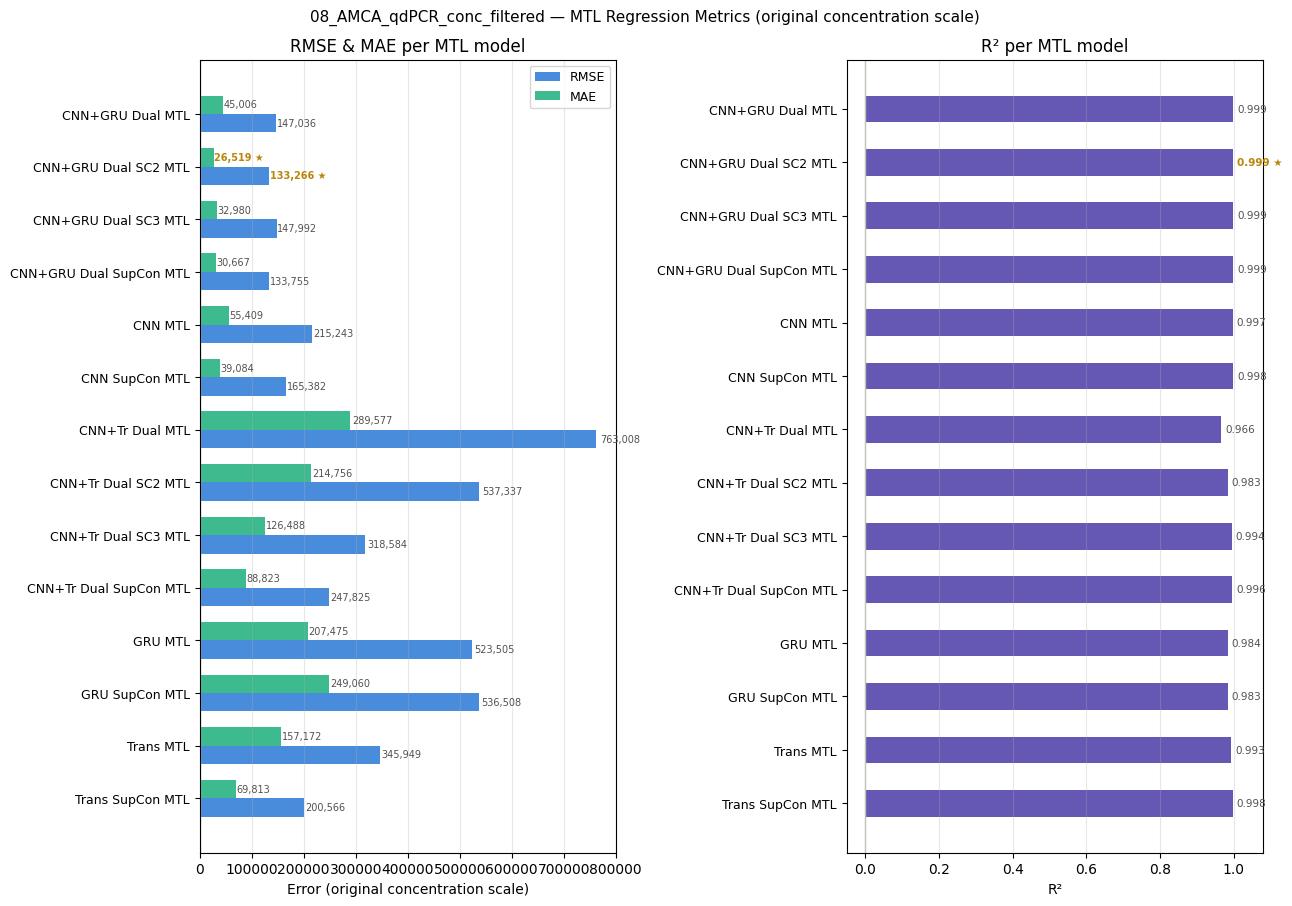

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual MTL,"147,036.12","45,006.16",0.9987,53793
CNN+GRU Dual SC2 MTL,"133,266.45","26,519.45",0.9990,53793
CNN+GRU Dual SC3 MTL,"147,991.92","32,980.36",0.9987,53793
CNN+GRU Dual SupCon MTL,"133,755.48","30,667.19",0.9990,53793
CNN MTL,"215,242.93","55,408.72",0.9973,53793
CNN SupCon MTL,"165,382.18","39,084.31",0.9984,53793
CNN+Tr Dual MTL,"763,008.20","289,576.51",0.9661,53793
CNN+Tr Dual SC2 MTL,"537,336.93","214,755.73",0.9832,53793
CNN+Tr Dual SC3 MTL,"318,584.08","126,487.90",0.9941,53793


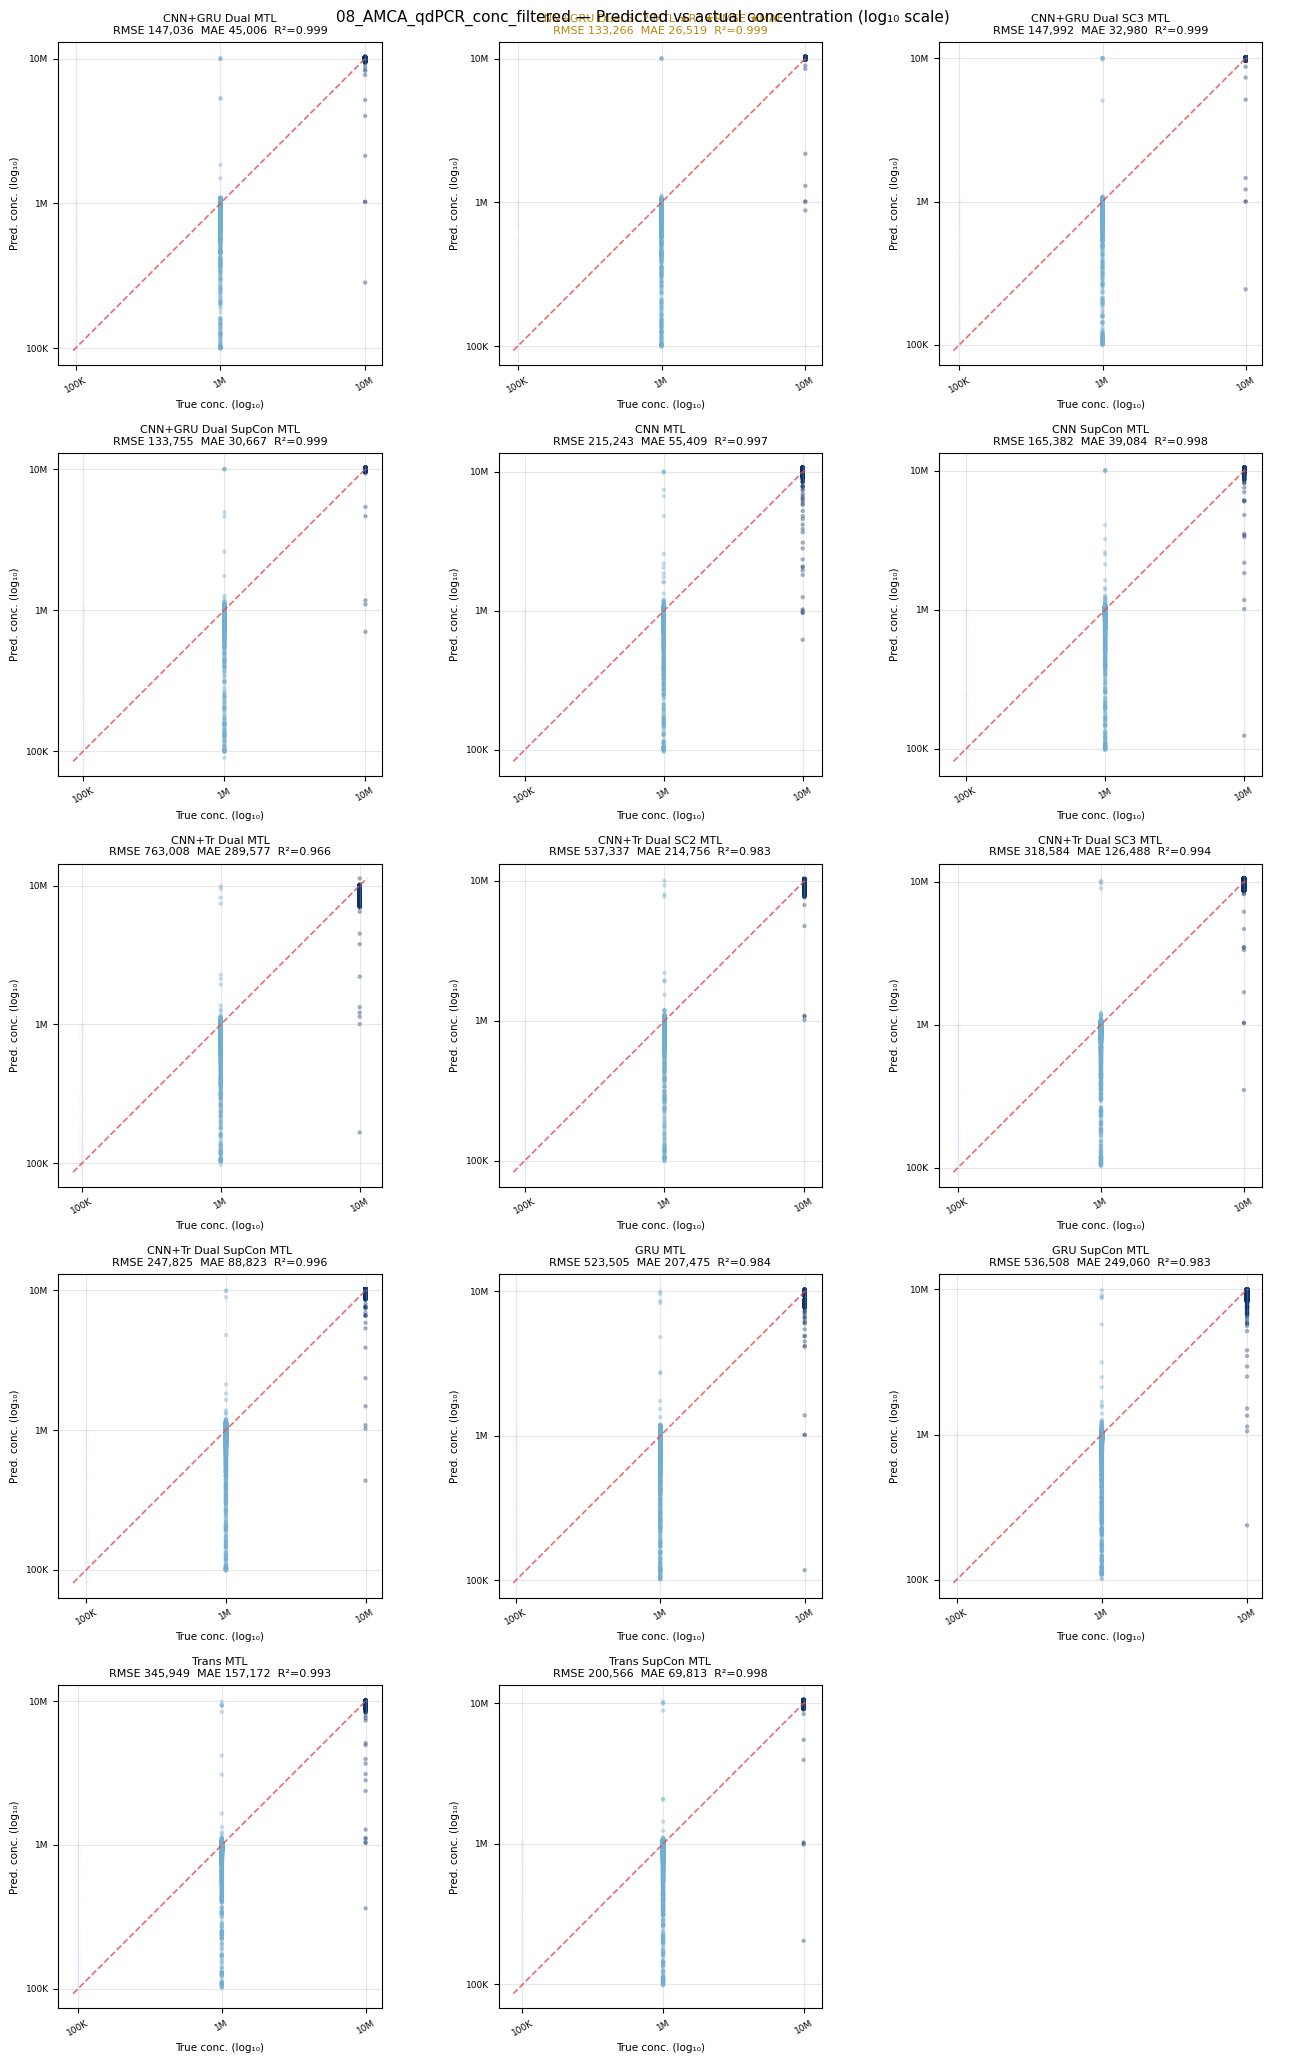

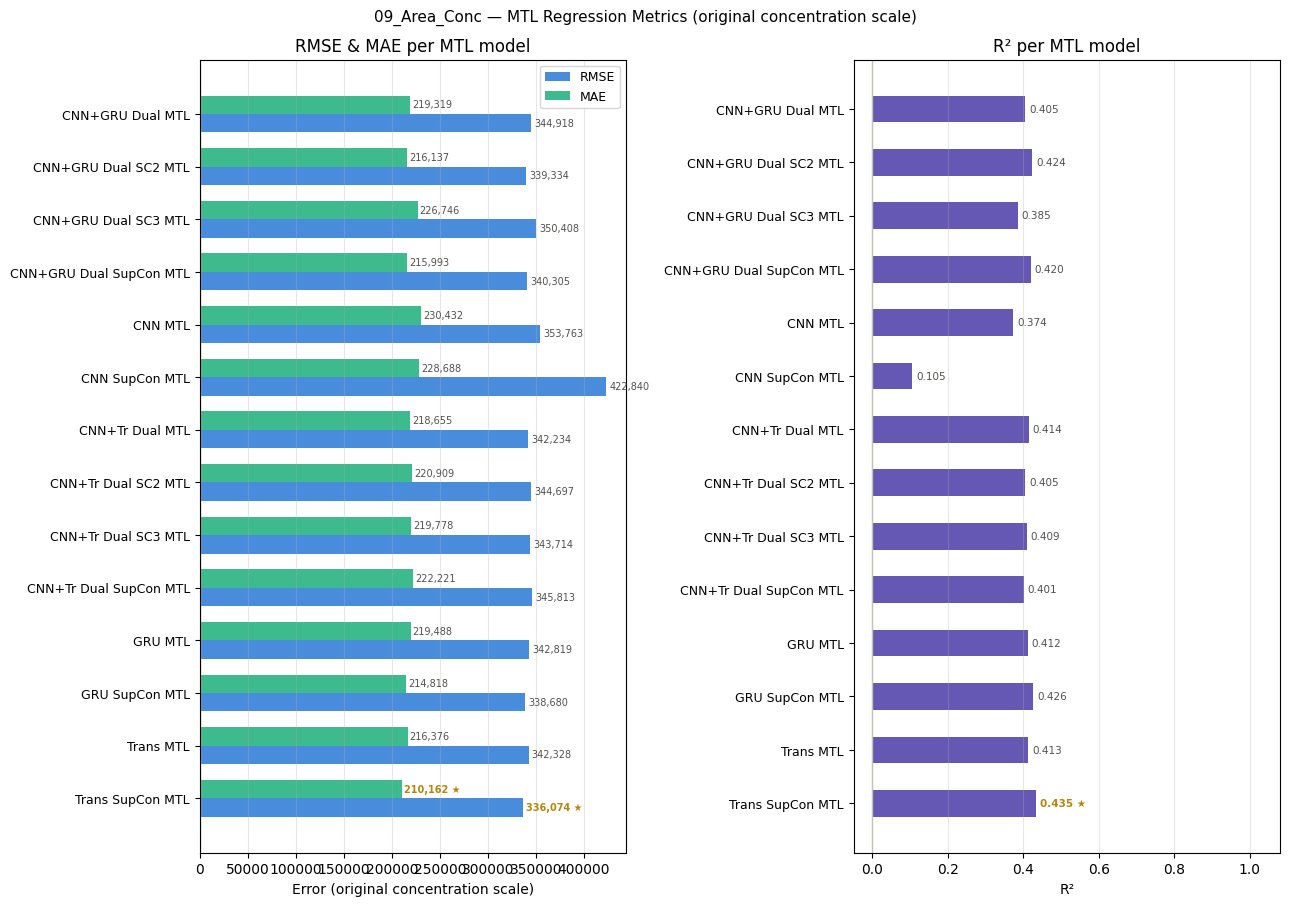

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual MTL,"344,918.18","219,318.60",0.4046,34650
CNN+GRU Dual SC2 MTL,"339,334.25","216,136.77",0.4237,34650
CNN+GRU Dual SC3 MTL,"350,407.83","226,746.40",0.3855,34650
CNN+GRU Dual SupCon MTL,"340,305.14","215,993.01",0.4204,34650
CNN MTL,"353,763.01","230,431.92",0.3736,34650
CNN SupCon MTL,"422,840.22","228,687.73",0.1051,34650
CNN+Tr Dual MTL,"342,233.68","218,654.96",0.4138,34650
CNN+Tr Dual SC2 MTL,"344,696.99","220,908.81",0.4053,34650
CNN+Tr Dual SC3 MTL,"343,714.47","219,778.13",0.4087,34650


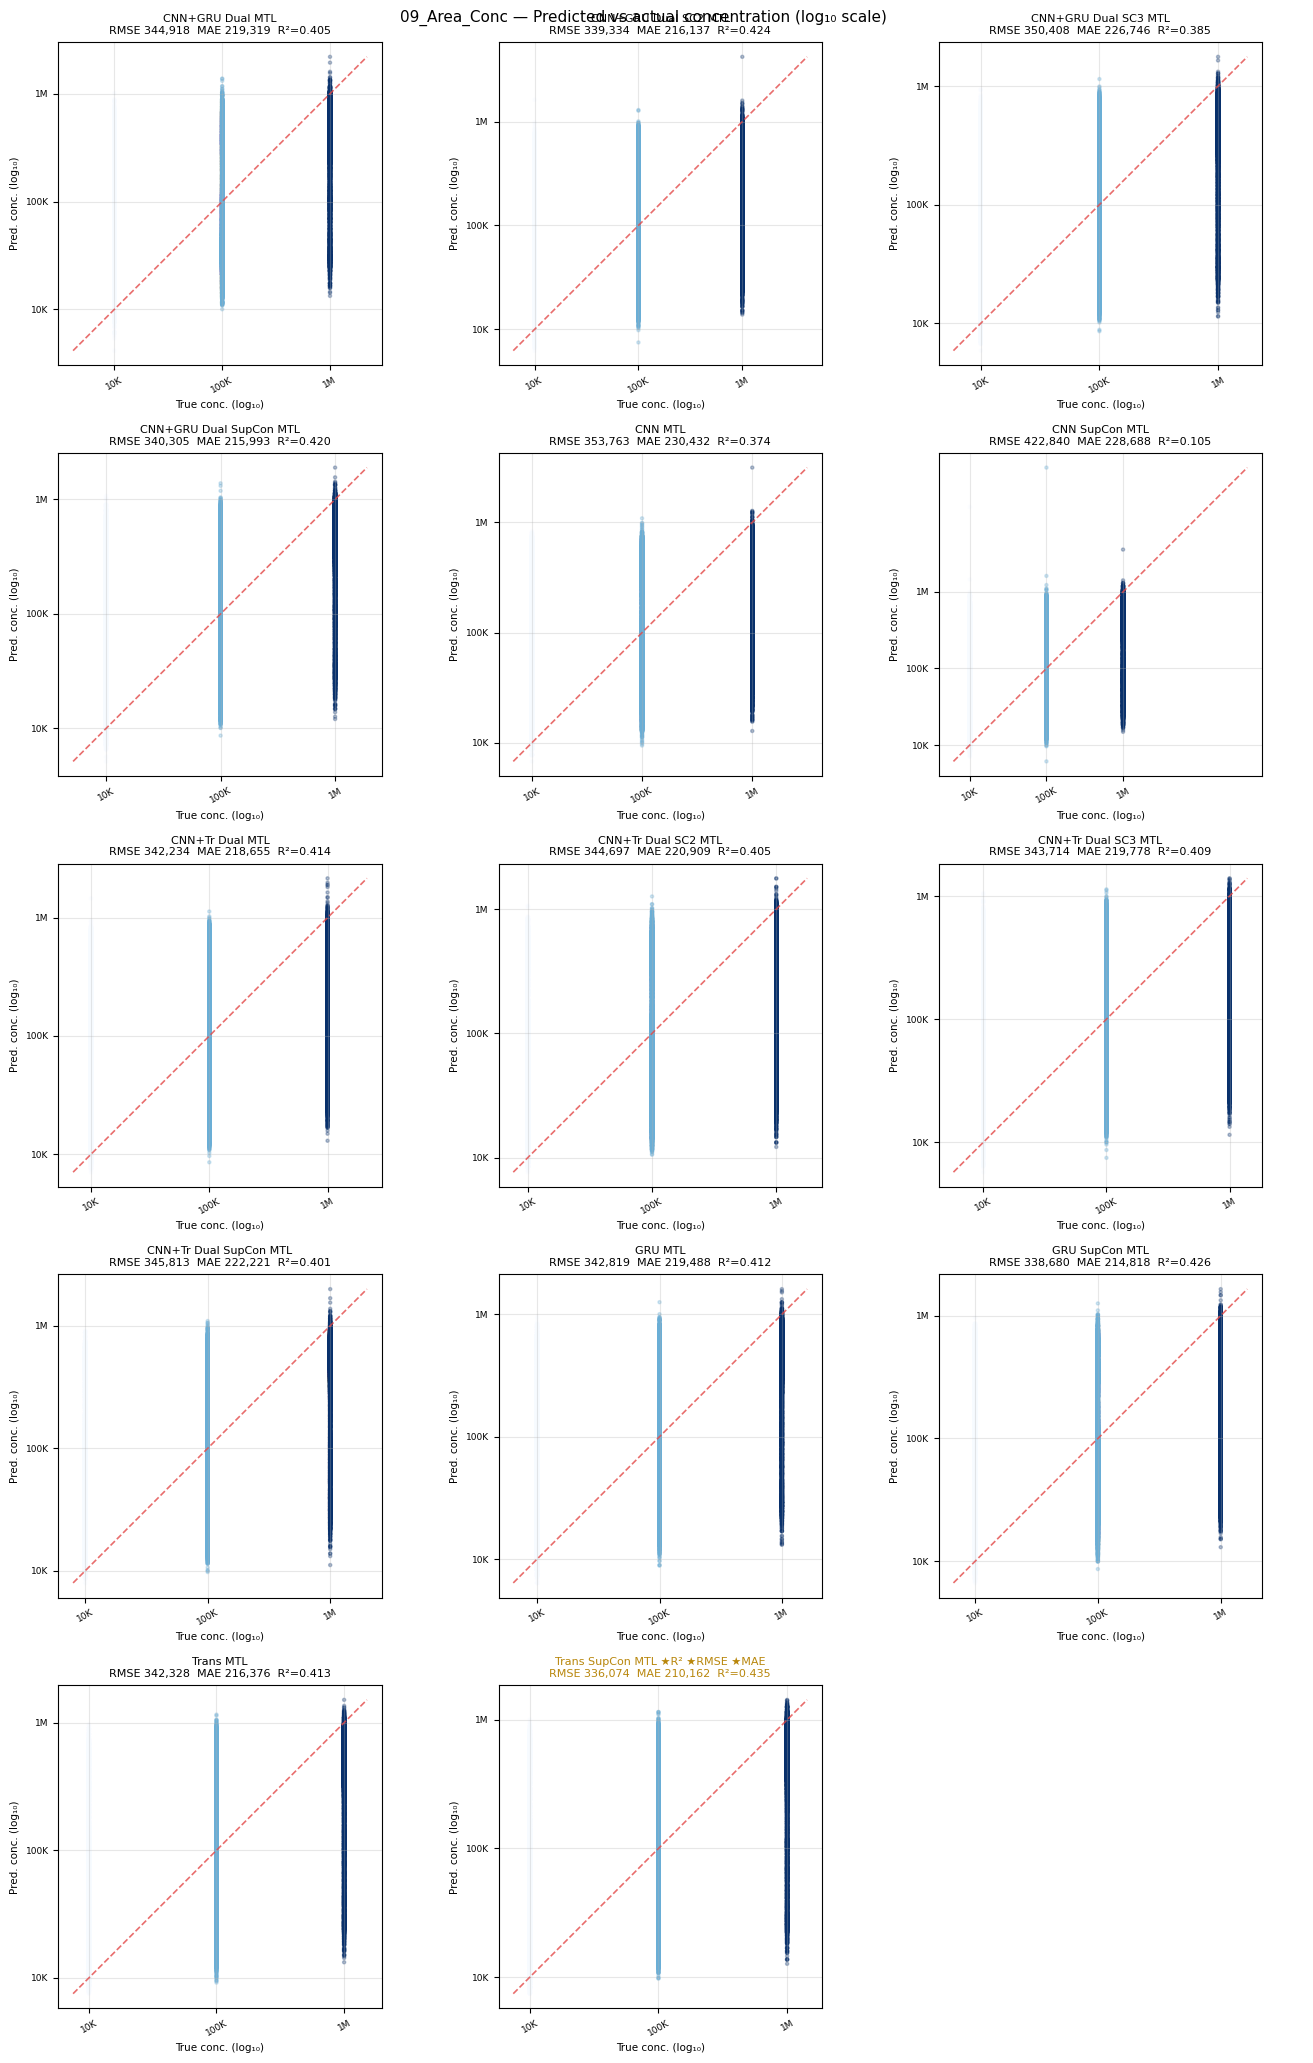

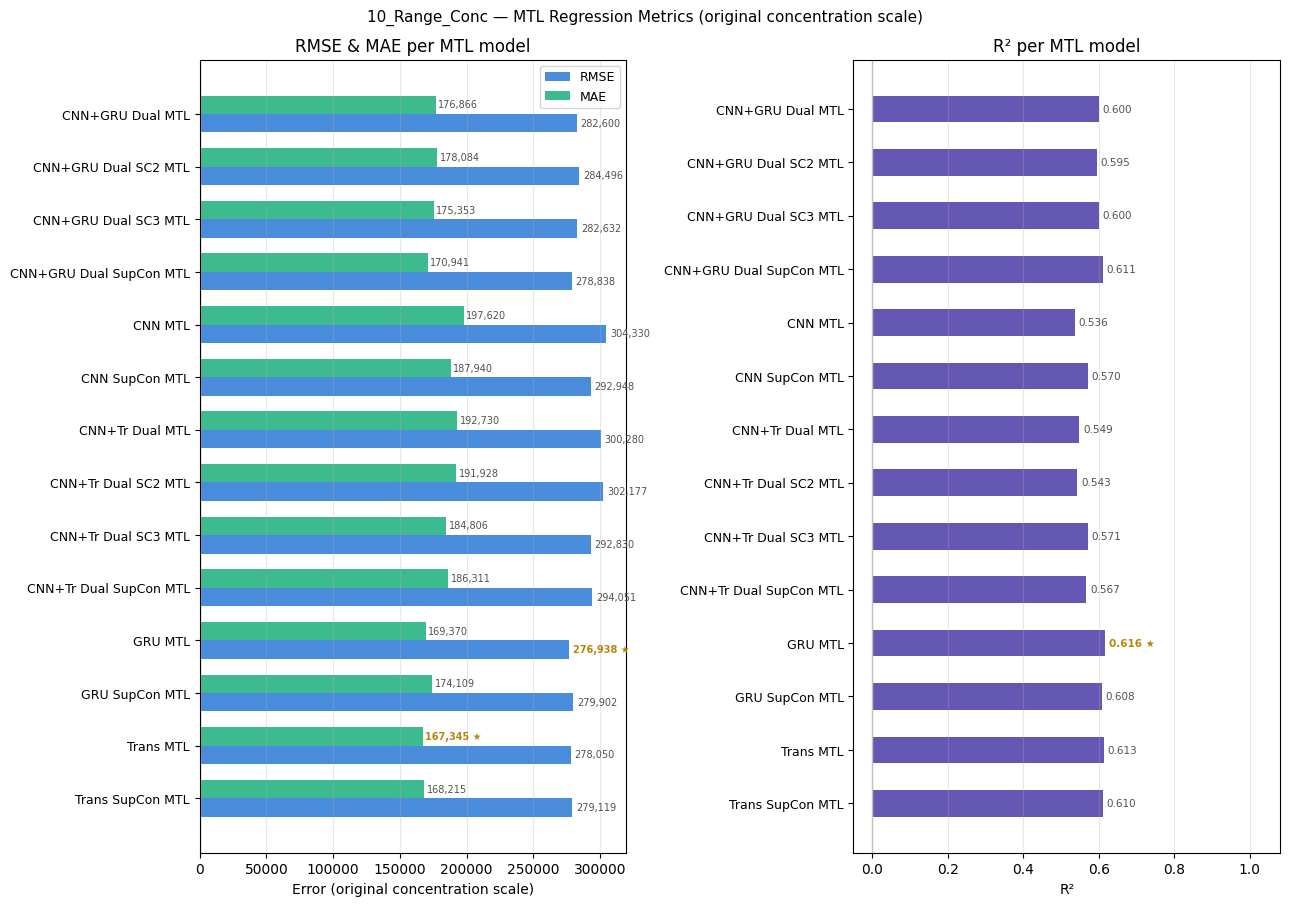

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual MTL,"282,599.63","176,865.64",0.6003,23100
CNN+GRU Dual SC2 MTL,"284,495.63","178,083.53",0.5949,23100
CNN+GRU Dual SC3 MTL,"282,632.00","175,352.75",0.6002,23100
CNN+GRU Dual SupCon MTL,"278,838.19","170,940.93",0.6109,23100
CNN MTL,"304,330.15","197,619.99",0.5365,23100
CNN SupCon MTL,"292,948.00","187,940.03",0.5705,23100
CNN+Tr Dual MTL,"300,280.36","192,730.34",0.5487,23100
CNN+Tr Dual SC2 MTL,"302,177.42","191,927.73",0.5430,23100
CNN+Tr Dual SC3 MTL,"292,829.51","184,806.04",0.5708,23100


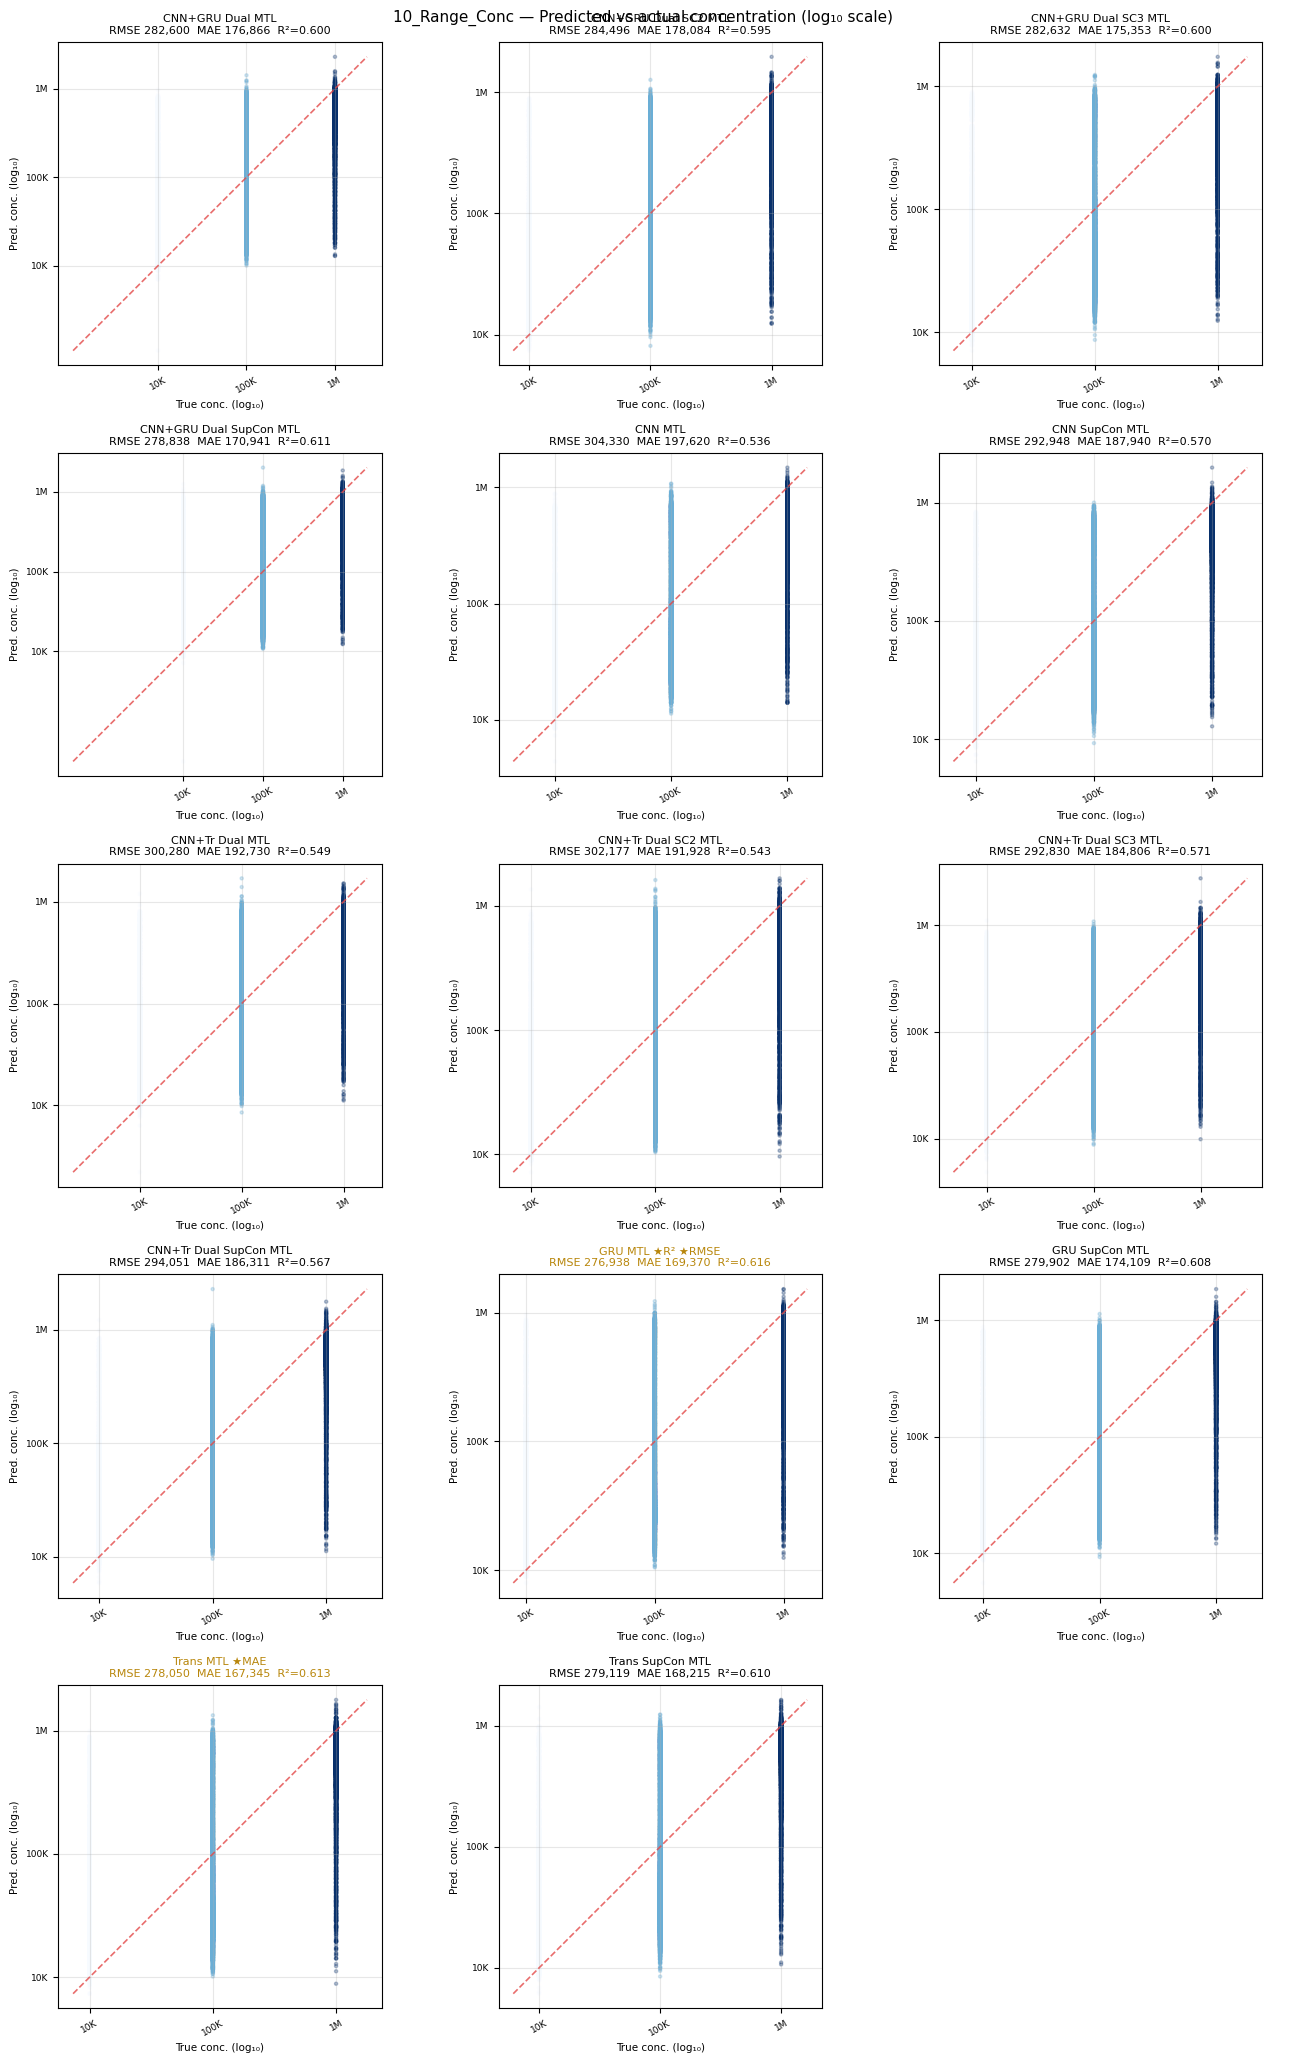

In [103]:
for _folder in _folders:
    _raw = load_results(_folder)
    if _raw is None:
        continue
    _res, _, _ = _get_res_entry(_raw, OUTLIER_FILTER)
    if _res is None:
        print(f'[!] {_folder}: no entry for filter={OUTLIER_FILTER!r}. Skipping.')
        continue

    reg_data = collect_reg_results(_res)

    # plot_stmtl_comparison(_res, _folder)
    plot_reg_metrics(reg_data, _folder)
    plot_reg_scatter(reg_data, _folder, log10_scale=True, max_models=20)
    # plot_reg_residuals(reg_data, _folder)

In [104]:
def plot_model_across_folders(folders, model_key, outlier_filter=OUTLIER_FILTER):
    methods = [
        ('ST',           model_key,                  '#b8def5'),
        ('MTL',          model_key + '_mtl',         '#fad7b0'),
        ('ST+SupCon 1',  model_key + '_supcon',      '#76c1e8'),
        ('MTL+SupCon 1', model_key + '_supcon_mtl',  '#f5ad74'),
        ('ST+SupCon 2',  model_key + '_supcon2',     '#3498d8'),
        ('MTL+SupCon 2', model_key + '_supcon2_mtl', '#e07c39'),
        ('ST+SupCon 3',  model_key + '_supcon3',     '#1a6fb5'),
        ('MTL+SupCon 3', model_key + '_supcon3_mtl', '#c05000'),
    ]

    def _fold_accs(res, key):
        pk = f'y_preds_AC_{key}_'
        if pk not in res or 'y_trues_' not in res:
            return None
        return np.array([np.mean(np.array(yt) == np.array(yp))
                         for yt, yp in zip(res['y_trues_'], res[pk])]) * 100

    data   = {label: ([], []) for label, *_ in methods}
    labels = []

    for folder in folders:
        all_res = load_results(folder)
        if all_res is None:
            continue
        res, _, _ = _get_res_entry(all_res, outlier_filter)
        if res is None:
            continue

        accs = {label: _fold_accs(res, key) for label, key, _ in methods}
        if all(v is None for v in accs.values()):
            continue

        labels.append(folder)
        for label, key, _ in methods:
            a = accs[label]
            data[label][0].append(a.mean() if a is not None else float('nan'))
            data[label][1].append(a.std()  if a is not None else 0)

    if not labels:
        print('No data found.')
        return

    n_bars = len(methods)
    n   = len(labels)
    w   = 0.10
    x   = np.arange(n)
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * w

    fig, ax = plt.subplots(figsize=(max(7, n * 2.0), 5))

    for (label, _, color), offset in zip(methods, offsets):
        means, stds = data[label]
        ax.bar(x + offset, means, w, yerr=stds, label=label,
               capsize=2, color=color,
               error_kw={'linewidth': 0.8, 'alpha': 0.5})
        for xi, (v, s) in enumerate(zip(means, stds)):
            if not (v != v):  # not NaN
                ax.text(xi + offset, v + s + 0.4, f'{v:.2f}',
                        ha='center', fontsize=7, color='black', rotation=90)

    all_vals = [v for lbl, *_ in methods for v in data[lbl][0] if v == v]
    if all_vals:
        ax.set_ylim(max(0, min(all_vals) - 1), 105)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Mean fold accuracy (%)', fontsize=10)
    ax.set_title(
        f'ST vs MTL × SupCon Versions Across Datasets\nModel: {model_key}',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=8, ncol=2)
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    plt.tight_layout()
    plt.show()

# -- Shared helpers -----------------------------------------------------------

def _extract_reg_folds(res, model_key, sentinel=-1.0):
    """Return list of (trues, preds) per fold, sentinel-masked."""
    pk = f'y_reg_preds_{model_key}_'
    tk = f'y_reg_trues_{model_key}_'
    if pk not in res or tk not in res:
        return None
    out = []
    for preds, trues in zip(res[pk], res[tk]):
        p, t = np.array(preds), np.array(trues)
        mask = t != sentinel
        if mask.sum() > 0:
            out.append((t[mask], p[mask]))
    return out or None


def _reg_metrics_fold(trues, preds):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from scipy.stats import pearsonr
    mae  = mean_absolute_error(trues, preds)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    r2   = r2_score(trues, preds)
    r, _ = pearsonr(trues, preds)
    return dict(MAE=mae, RMSE=rmse, R2=r2, r=r)


# -- Across-folders versions --------------------------------------------------

def plot_reg_metrics_across_folders(folders, model_key,
                                     outlier_filter=OUTLIER_FILTER, sentinel=-1.0):
    """Bar chart of regression metrics (mean +/- std across folds) for each dataset."""
    data = {}
    for folder in folders:
        all_res = load_results(folder)
        if all_res is None:
            continue
        res, _, _ = _get_res_entry(all_res, outlier_filter)
        if res is None:
            continue
        fold_pairs = _extract_reg_folds(res, model_key, sentinel)
        if fold_pairs is None:
            continue
        data[folder] = [_reg_metrics_fold(t, p) for t, p in fold_pairs]

    if not data:
        print('No regression data found.')
        return

    labels     = list(data.keys())
    metric_keys = ['MAE', 'RMSE', 'R2', 'r']
    x = np.arange(len(labels))

    fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
    for ax, m in zip(axes, metric_keys):
        means = [np.mean([f[m] for f in data[fld]]) for fld in labels]
        stds  = [np.std( [f[m] for f in data[fld]]) for fld in labels]
        ax.bar(x, means, yerr=stds, capsize=4, alpha=0.85, color='steelblue')
        for xi, (mn, sd) in enumerate(zip(means, stds)):
            ax.text(xi, mn + sd + (max(means) - min(means)) * 0.03,
                    f'{mn:.3f}', ha='center', fontsize=7.5)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
        ax.set_title(m, fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linewidth=0.7)
        if m in ('R2', 'r'):
            ax.set_ylim(top=1.05)

    fig.suptitle(f'Regression metrics  [{model_key}]  across datasets',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_reg_scatter_across_folders(folders, model_key, log10_scale=True,
                                     outlier_filter=OUTLIER_FILTER, sentinel=-1.0):

    data = {}
    for folder in folders:
        all_res = load_results(folder)
        if all_res is None:
            continue
        res, _, _ = _get_res_entry(all_res, outlier_filter)
        if res is None:
            continue
        fold_pairs = _extract_reg_folds(res, model_key, sentinel)
        if fold_pairs is None:
            continue
        data[folder] = fold_pairs

    if not data:
        print('No regression data found.')
        return

    labels = list(data.keys())
    fig, axes = plt.subplots(1, len(labels), figsize=(4.5 * len(labels), 4.2), squeeze=False)

    for ax, folder in zip(axes[0], labels):
        trues_raw = np.concatenate([t for t, _ in data[folder]])
        preds_raw = np.concatenate([p for _, p in data[folder]])

        m = _reg_metrics_fold(trues_raw, preds_raw)

        if log10_scale:
            t_plot = np.log10(np.maximum(trues_raw, 0.1))
            p_plot = np.log10(np.maximum(preds_raw, 0.1))
        else:
            t_plot, p_plot = trues_raw, preds_raw

        xlabel, ylabel = 'True concentration', 'Pred. concentration'

        ax.scatter(t_plot, p_plot, s=5, alpha=0.3,
                   c=t_plot, cmap='Blues',
                   vmin=t_plot.min(), vmax=t_plot.max(),
                   rasterized=True)

        lo = min(t_plot.min(), p_plot.min())
        hi = max(t_plot.max(), p_plot.max())
        ax.plot([lo, hi], [lo, hi], color='#e34948', linewidth=1.2,
                linestyle='--', alpha=0.8)

        unique_c = sorted(np.unique(np.round(trues_raw, 0)))
        if log10_scale:
            ticks = np.log10(np.maximum(unique_c, 0.1))
        else:
            ticks = unique_c
        ax.set_xticks(ticks)
        ax.set_xticklabels([_conc_label(c) for c in unique_c], rotation=30, fontsize=6.5)
        ax.set_yticks(ticks)
        ax.set_yticklabels([_conc_label(c) for c in unique_c], fontsize=6.5)

        ax.set_title(
            f"{folder}\nRMSE {m['RMSE']:,.0f}  MAE {m['MAE']:,.0f}  R²={m['R2']:.3f}",
            fontsize=8)
        ax.set_xlabel(xlabel, fontsize=7.5)
        ax.set_ylabel(ylabel, fontsize=7.5)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(alpha=0.3, linewidth=0.8)

    scale_label = 'log₁₀ scale' if log10_scale else 'original scale'
    fig.suptitle(f'Predicted vs Actual Concentration Across Datasets (Model: {model_key})',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

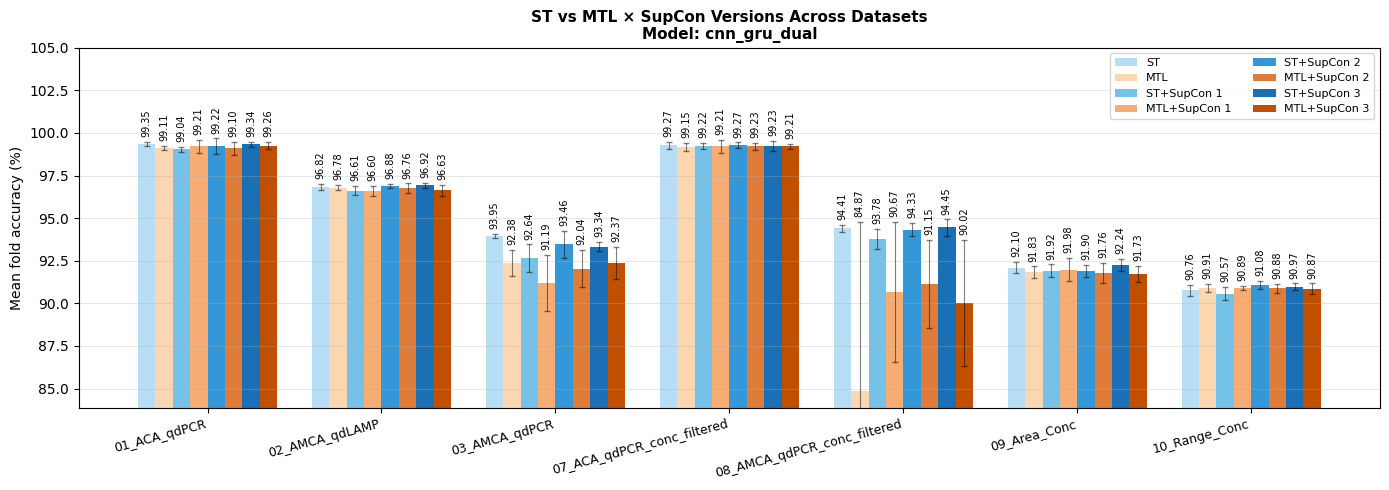

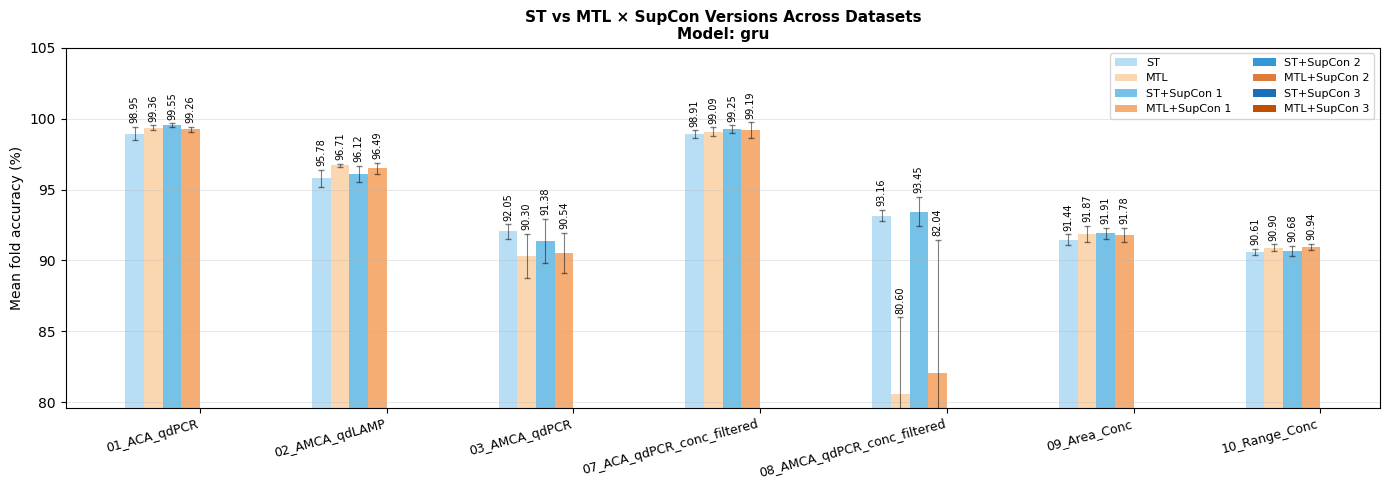

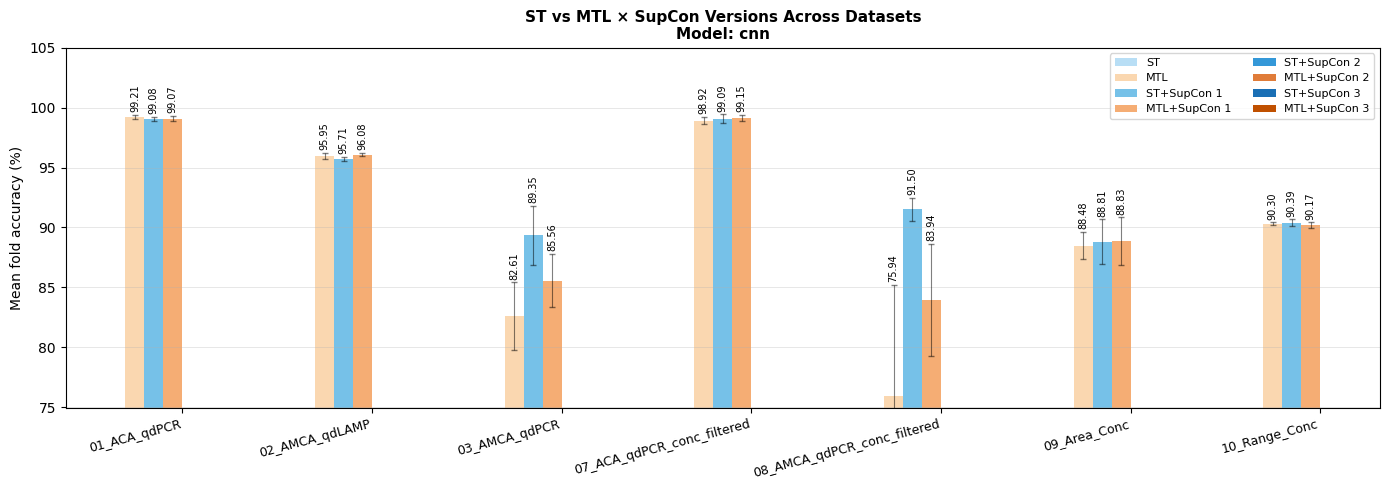

In [105]:
# _folders = ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered']
plot_model_across_folders(_folders,model_key='cnn_gru_dual',outlier_filter=None)
plot_model_across_folders(_folders,model_key='gru',outlier_filter=None)
plot_model_across_folders(_folders,model_key='cnn',outlier_filter=None)
# plot_reg_metrics_across_folders(_folders, model_key='cnn_gru_dual_mtl')
# plot_reg_scatter_across_folders(_folders, model_key='cnn_gru_dual_mtl', log10_scale=True)


In [106]:
def plot_conc_distribution_per_folder(folders):
    """One bar chart per dataset: x = concentration level, y = sample count."""
    n = len(folders)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), squeeze=False)

    for ax, folder in zip(axes[0], folders):
        d = load_folder_data(folder)
        valid = ~np.isnan(d['concentration'])
        con_v = d['concentration'][valid]

        sorted_conc = sorted(np.unique(con_v))
        counts      = [int(np.sum(con_v == c)) for c in sorted_conc]
        col_labels  = [_conc_label(c) for c in sorted_conc]

        bars = ax.bar(range(len(sorted_conc)), counts, color='steelblue', alpha=0.85, edgecolor='white')
        for xi, v in enumerate(counts):
            ax.text(xi, v + max(counts) * 0.02, str(v),
                    ha='center', fontsize=8.5, fontweight='bold', color='steelblue')

        ax.set_xticks(range(len(sorted_conc)))
        ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel('Sample count', fontsize=9)
        ax.set_title(f'{folder}\n(n={sum(counts)})', fontsize=9, fontweight='bold')
        ax.set_ylim(0, max(counts) * 1.15)
        ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    fig.suptitle('Sample count by concentration — per dataset', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


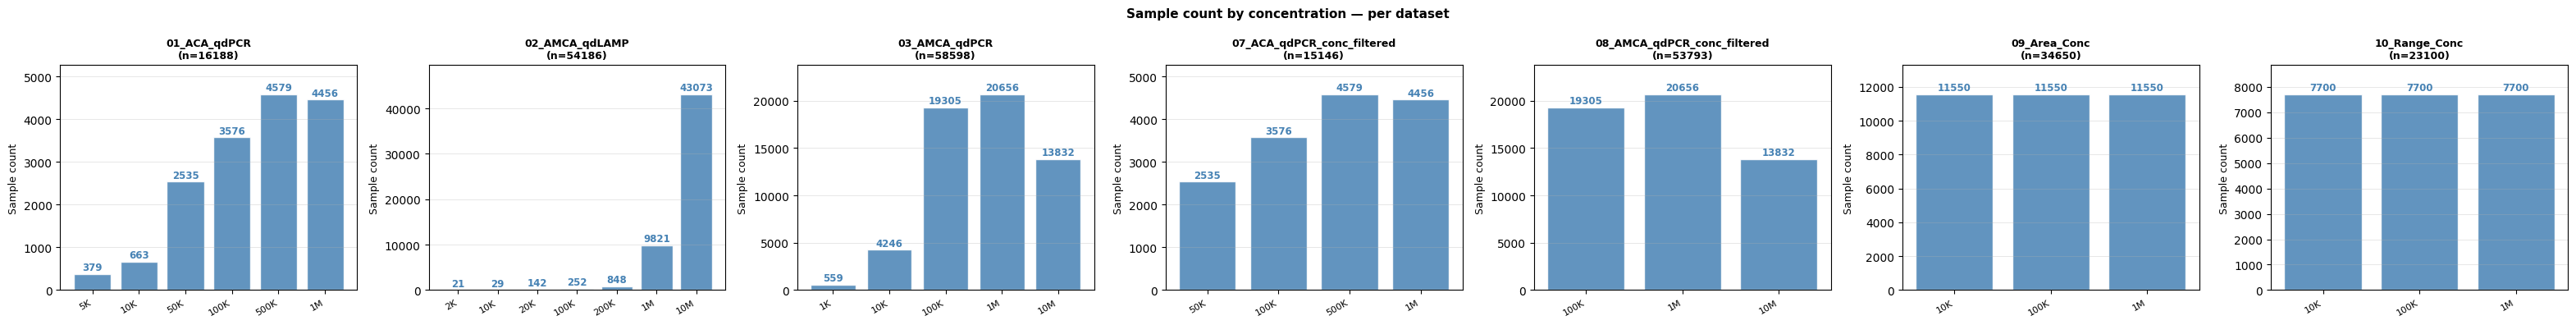

In [107]:
plot_conc_distribution_per_folder(_folders)


---
## Section 9 · RCFD Model Comparison

All 24 RCFD (Regression-Conditioned Feature Dual) variants — 3 early encoders × 2 dual backbones × 4 SupCon variants — compared against each other and against existing ST/MTL/SupCon baselines.

| Function | Question answered |
|---|---|
| `plot_rcfd_overview` | **9a** — Which encoder+dual+SC variant wins? (heat map of all 24) |
| `plot_rcfd_vs_baseline` | **9b** — Does RCFD beat the vanilla dual backbone? (bars vs dashed ST/MTL lines) |
| `plot_rcfd_reg_comparison` | **9c** — Which early encoder predicts concentration best? (RMSE / R²) |
| `plot_rcfd_across_folders` | **9d** — Is RCFD gain consistent across datasets? (cross-folder, per encoder) |

In [108]:
# ── RCFD section constants & helper ──────────────────────────────────────────

_RCFD_ENCS  = ['cnn', 'gru', 'trans']
_RCFD_DUALS = ['cgd', 'ctd']
_RCFD_DUAL_LABELS   = {'cgd': 'CNN+GRU',   'ctd': 'CNN+Trans'}
_RCFD_ENC_LABELS    = {'cnn': 'CNN', 'gru': 'GRU', 'trans': 'Trans'}
_RCFD_ENC_COLORS    = {'cnn': '#3498d8', 'gru': '#e07c39', 'trans': '#2e8b57'}
_RCFD_SC_VARIANTS   = [('Base', ''), ('SC1', '_supcon_mtl'),
                        ('SC2', '_supcon2_mtl'), ('SC3', '_supcon3_mtl')]
_RCFD_SC_COLORS     = ['#cce5f7', '#76c1e8', '#2a78d6', '#1a4fa0']
_RCFD_DUAL_BASELINE = {'cgd': 'cnn_gru_dual', 'ctd': 'cnn_trans_dual'}


def _rcfd_acc(res, key):
    """Mean ± std fold accuracy for *key*; (None, None) if absent.

    Uses config.MODEL_KEY_MAP for storage-key resolution so that keys with
    non-obvious mappings (e.g. 'cnn' → 'y_preds_AC_', 'trans' variants) are
    handled correctly. Falls back to f'y_preds_AC_{key}_' for RCFD keys and
    any others not in the map.
    """
    pk = config.MODEL_KEY_MAP.get(key, (f'y_preds_AC_{key}_',))[0]
    if pk not in res or 'y_trues_' not in res:
        return None, None
    accs = [np.mean(np.array(yt) == np.array(yp)) * 100
            for yt, yp in zip(res['y_trues_'], res[pk])]
    return (np.mean(accs), np.std(accs)) if accs else (None, None)


def plot_rcfd_overview(res_entry, title=''):
    """9a — Accuracy heat map: all 24 RCFD variants at a glance.

    Rows = SupCon variant (Base / SC1 / SC2 / SC3)
    Cols = encoder × dual backbone  (CNN/CGD  CNN/CTD  GRU/CGD  GRU/CTD  Trans/CGD  Trans/CTD)
    Cell = mean ± std fold accuracy
    """
    col_bases  = [f'{e}_rcfd_{d}' for e in _RCFD_ENCS for d in _RCFD_DUALS]
    col_labels = [f'{_RCFD_ENC_LABELS[e]}/{d.upper()}' for e in _RCFD_ENCS for d in _RCFD_DUALS]
    n_r, n_c   = len(_RCFD_SC_VARIANTS), len(col_bases)

    mat = np.full((n_r, n_c), np.nan)
    std = np.full_like(mat, np.nan)
    for ri, (_, sfx) in enumerate(_RCFD_SC_VARIANTS):
        for ci, base in enumerate(col_bases):
            m, s = _rcfd_acc(res_entry, base + sfx)
            if m is not None:
                mat[ri, ci], std[ri, ci] = m, s

    if np.all(np.isnan(mat)):
        print('[!] No RCFD results found.'); return

    vmin = max(0, np.nanmin(mat) - 2)
    vmax = min(100, np.nanmax(mat) + 1)
    fig, ax = plt.subplots(figsize=(12, 3.8))
    im = ax.imshow(mat, cmap='Blues', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, label='Mean acc (%)', fraction=0.018, pad=0.01)

    ax.set_xticks(range(n_c)); ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(n_r))
    ax.set_yticklabels([lbl for lbl, _ in _RCFD_SC_VARIANTS], fontsize=10)

    for xi in range(2, n_c, 2):           # white separator between encoder groups
        ax.axvline(xi - 0.5, color='white', linewidth=2.5)

    for ri in range(n_r):
        for ci in range(n_c):
            if np.isnan(mat[ri, ci]):
                ax.text(ci, ri, '—', ha='center', va='center', fontsize=9, color='#bbb')
            else:
                bright = mat[ri, ci] > (vmin + vmax) * 0.6
                ax.text(ci, ri, f'{mat[ri,ci]:.2f}\n±{std[ri,ci]:.2f}',
                        ha='center', va='center', fontsize=7.5,
                        color='white' if bright else '#222')

    ax.set_title(f'{title} — RCFD: all 24 variants', fontsize=11)
    plt.tight_layout()
    plt.show()

    rows = []
    for ri, (sc_lbl, sfx) in enumerate(_RCFD_SC_VARIANTS):
        row = {'SupCon': sc_lbl}
        for ci, (_, lbl) in enumerate(zip(col_bases, col_labels)):
            m, s = mat[ri, ci], std[ri, ci]
            row[lbl] = f'{m:.2f}±{s:.2f}' if not np.isnan(m) else '—'
        rows.append(row)
    display(pd.DataFrame(rows).set_index('SupCon'))

In [109]:
def plot_rcfd_vs_baseline(res_entry, title=''):
    """9b — RCFD accuracy vs SC-matched non-RCFD dual-backbone baselines.

    Two panels (CGD = CNN+GRU dual / CTD = CNN+Trans dual).
    Per panel:
      x     = SupCon variant (Base / SC1 / SC2 / SC3)
      bars  = early encoder (CNN / GRU / Trans)
      lines = SC-matched non-RCFD dual baseline at each x:
              grey square  = dual ST+SC{n}  (cnn_gru_dual_supcon{n})
              orange diamond = dual MTL+SC{n} (cnn_gru_dual_supcon{n}_mtl)
    """
    # Maps SC index → suffix for non-RCFD dual baseline
    _ST_SFX  = {0: '',          1: '_supcon',     2: '_supcon2',     3: '_supcon3'}
    _MTL_SFX = {0: '_mtl',      1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

    for ax, dual in zip(axes, _RCFD_DUALS):
        dlbl = _RCFD_DUAL_LABELS[dual]
        bb   = _RCFD_DUAL_BASELINE[dual]

        n_sc  = len(_RCFD_SC_VARIANTS)
        n_enc = len(_RCFD_ENCS)
        w     = 0.22
        x     = np.arange(n_sc)
        enc_offsets = (np.arange(n_enc) - (n_enc - 1) / 2) * w

        any_data = False
        for ei, enc in enumerate(_RCFD_ENCS):
            xs, ms, ss = [], [], []
            for si, (_, sfx) in enumerate(_RCFD_SC_VARIANTS):
                m, s = _rcfd_acc(res_entry, f'{enc}_rcfd_{dual}{sfx}')
                if m is not None:
                    xs.append(si); ms.append(m); ss.append(s)
            if not ms:
                continue
            any_data = True
            bars = ax.bar(np.array(xs) + enc_offsets[ei], ms, w,
                          yerr=ss, label=_RCFD_ENC_LABELS[enc],
                          color=_RCFD_ENC_COLORS[enc], alpha=0.85,
                          capsize=2, error_kw={'linewidth': 0.8, 'alpha': 0.5})
            for bar, mv, sv in zip(bars, ms, ss):
                ax.text(bar.get_x() + w / 2, mv + sv + 0.3,
                        f'{mv:.2f}', ha='center', va='bottom',
                        fontsize=6.5, rotation=90, color='#444')

        if not any_data:
            ax.text(0.5, 0.5, 'No RCFD results', ha='center', va='center',
                    transform=ax.transAxes, color='#aaa', fontsize=11)

        # SC-matched reference lines (one point per x position)
        for ref_label, sfx_map, color, marker in [
            (f'{dlbl} ST+SC',  _ST_SFX,  '#666',    's'),
            (f'{dlbl} MTL+SC', _MTL_SFX, '#c05000', 'D'),
        ]:
            ref_vals = []
            for si in range(n_sc):
                m, _ = _rcfd_acc(res_entry, bb + sfx_map[si])
                ref_vals.append(m if m is not None else np.nan)
            if not all(np.isnan(v) for v in ref_vals):
                ax.plot(x, ref_vals, color=color, linewidth=1.5,
                        linestyle='--', marker=marker, markersize=6,
                        label=ref_label, zorder=5)
                for xi, v in enumerate(ref_vals):
                    if not np.isnan(v):
                        ax.text(xi, v + 0.4, f'{v:.2f}',
                                ha='center', va='bottom', fontsize=6.5,
                                color=color)

        ax.set_xticks(x)
        ax.set_xticklabels([lbl for lbl, _ in _RCFD_SC_VARIANTS], fontsize=10)
        ax.set_xlabel('SupCon Variant', fontsize=9)
        ax.set_title(f'{dlbl}', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8, ncol=2, loc='lower right')
        ax.grid(axis='y', alpha=0.3, linewidth=0.8)

        all_vals = [m for enc in _RCFD_ENCS for _, sfx in _RCFD_SC_VARIANTS
                    for m, _ in [_rcfd_acc(res_entry, f'{enc}_rcfd_{dual}{sfx}')] if m is not None]
        for sfx_map in [_ST_SFX, _MTL_SFX]:
            for si in range(n_sc):
                m, _ = _rcfd_acc(res_entry, bb + sfx_map[si])
                if m is not None:
                    all_vals.append(m)
        if all_vals:
            ax.set_ylim(max(0, min(all_vals) - 3), min(100, max(all_vals) + 8))

    axes[0].set_ylabel('Mean fold accuracy (%)', fontsize=10)
    fig.suptitle(f'{title} — RCFD vs SC-matched non-RCFD dual baselines\n'
                 f'(squares = ST+SC, diamonds = MTL+SC at matching SC level)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

In [110]:
def plot_rcfd_reg_comparison(res_entry, title=''):
    """9c — Early-encoder regression quality (RMSE / R²) across RCFD base variants.

    All RCFD base models share one early encoder dedicated to regression.
    This shows whether CNN / GRU / Trans encoders differ in concentration prediction.
    Uses the SC=0 (base) variant's reg outputs; SC variants train the same encoder.
    """
    REG_SENTINEL = -1.0
    col_bases  = [f'{e}_rcfd_{d}' for e in _RCFD_ENCS for d in _RCFD_DUALS]
    col_labels = [f'{_RCFD_ENC_LABELS[e]}/{d.upper()}' for e in _RCFD_ENCS for d in _RCFD_DUALS]

    rmse_vals, mae_vals, r2_vals, valid_names = [], [], [], []
    for key, name in zip(col_bases, col_labels):
        rk = f'y_reg_preds_{key}_'
        tk = f'y_reg_trues_{key}_'
        if rk not in res_entry or tk not in res_entry:
            continue
        p_all = np.concatenate(res_entry[rk])
        t_all = np.concatenate(res_entry[tk])
        vm = t_all != REG_SENTINEL
        if vm.sum() < 2:
            continue
        p, t  = p_all[vm], t_all[vm]
        rmse  = float(np.sqrt(np.mean((p - t) ** 2)))
        mae   = float(np.mean(np.abs(p - t)))
        ss    = float(np.sum((t - t.mean()) ** 2))
        r2    = 1.0 - float(np.sum((t - p) ** 2)) / ss if ss > 0 else 0.0
        rmse_vals.append(rmse); mae_vals.append(mae)
        r2_vals.append(r2);     valid_names.append(name)

    if not valid_names:
        print('[!] No RCFD regression results found.'); return

    _GOLD = '#b8860b'
    best_rmse = int(np.argmin(rmse_vals))
    best_r2   = int(np.argmax(r2_vals))
    n = len(valid_names)
    h = max(3.5, n * 0.55 + 1.5)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, h))
    y = np.arange(n)
    bw = 0.35

    ax1.barh(y + bw/2, rmse_vals, bw, color='#2a78d6', alpha=0.85, label='RMSE')
    ax1.barh(y - bw/2, mae_vals,  bw, color='#1baf7a', alpha=0.85, label='MAE')
    for i, (r, m) in enumerate(zip(rmse_vals, mae_vals)):
        star = ' ★' if i == best_rmse else ''
        ax1.text(r * 1.01, i + bw/2, f'{r:,.0f}{star}', va='center', fontsize=8,
                 color=_GOLD if i == best_rmse else '#555',
                 fontweight='bold' if i == best_rmse else 'normal')
        ax1.text(m * 1.01, i - bw/2, f'{m:,.0f}', va='center', fontsize=8, color='#555')
    ax1.set_yticks(y); ax1.set_yticklabels(valid_names, fontsize=9)
    ax1.invert_yaxis(); ax1.legend(fontsize=9)
    ax1.set_xlabel('Error (original concentration scale)')
    ax1.set_title('RMSE & MAE')
    ax1.grid(axis='x', alpha=0.3)

    ax2.barh(y, r2_vals, 0.5, color='#4a3aa7', alpha=0.85)
    for i, v in enumerate(r2_vals):
        star = ' ★' if i == best_r2 else ''
        ax2.text(max(v, 0) + 0.01, i, f'{v:.3f}{star}', va='center', fontsize=8,
                 color=_GOLD if i == best_r2 else '#555',
                 fontweight='bold' if i == best_r2 else 'normal')
    ax2.set_yticks(y); ax2.set_yticklabels(valid_names, fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlim(-0.05, 1.1); ax2.axvline(0, color='#ccc', linewidth=1)
    ax2.set_xlabel('R²'); ax2.set_title('R² (higher = better)')
    ax2.grid(axis='x', alpha=0.3)

    fig.suptitle(f'{title} — RCFD early-encoder regression quality', fontsize=11)
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame([{'Model': n, 'RMSE': f'{r:,.2f}', 'MAE': f'{m:,.2f}', 'R²': f'{r2:.4f}'}
                       for n, r, m, r2 in zip(valid_names, rmse_vals, mae_vals, r2_vals)])
    display(df.set_index('Model'))

In [111]:
def plot_rcfd_across_folders(folders, dual='cgd', outlier_filter=OUTLIER_FILTER):
    """9d — RCFD accuracy across datasets: one panel per early encoder.

    Three panels (CNN / GRU / Trans encoder).  Per panel:
      x = folder, bars = SupCon variant (Base→SC3, light→dark blue),
      tick marks (_) = non-RCFD ST and MTL dual-backbone reference per folder.
    """
    dlbl = _RCFD_DUAL_LABELS[dual]
    bb   = _RCFD_DUAL_BASELINE[dual]

    entries = {}
    for folder in folders:
        raw = load_results(folder)
        if raw is None:
            continue
        res, _, _ = _get_res_entry(raw, outlier_filter)
        if res is not None:
            entries[folder] = res

    if not entries:
        print('No results found.'); return

    folder_list = list(entries.keys())
    n_folders   = len(folder_list)
    x           = np.arange(n_folders)
    n_sc        = len(_RCFD_SC_VARIANTS)
    w           = 0.18
    offsets     = (np.arange(n_sc) - (n_sc - 1) / 2) * w

    panel_w = max(5.0, n_folders * 2.2)
    fig, axes = plt.subplots(1, len(_RCFD_ENCS),
                              figsize=(panel_w * len(_RCFD_ENCS), 5.5),
                              sharey=True)

    for ax, enc in zip(axes, _RCFD_ENCS):
        for si, ((sc_lbl, sfx), color, offset) in enumerate(
                zip(_RCFD_SC_VARIANTS, _RCFD_SC_COLORS, offsets)):
            ms, ss = [], []
            for fld in folder_list:
                m, s = _rcfd_acc(entries[fld], f'{enc}_rcfd_{dual}{sfx}')
                ms.append(m if m is not None else np.nan)
                ss.append(s if s is not None else 0.0)
            if all(np.isnan(v) for v in ms):
                continue
            bars = ax.bar(x + offset, ms, w, yerr=ss, color=color,
                          label=sc_lbl, capsize=2,
                          error_kw={'linewidth': 0.8, 'alpha': 0.5})
            for bar, mv, sv in zip(bars, ms, ss):
                if not np.isnan(mv):
                    ax.text(bar.get_x() + w / 2, mv + sv + 0.3,
                            f'{mv:.2f}', ha='center', fontsize=6, rotation=90)

        for xi, fld in enumerate(folder_list):
            st_v,  _ = _rcfd_acc(entries[fld], bb)
            mtl_v, _ = _rcfd_acc(entries[fld], bb + '_mtl')
            if st_v is not None:
                ax.plot(xi, st_v, marker='_', markersize=22,
                        color='#888', linewidth=2.5, zorder=5,
                        label='ST ref' if xi == 0 else '_nolegend_')
            if mtl_v is not None:
                ax.plot(xi, mtl_v, marker='_', markersize=22,
                        color='#c05000', linewidth=2.5, zorder=5,
                        label='MTL ref' if xi == 0 else '_nolegend_')

        ax.set_xticks(x)
        ax.set_xticklabels(folder_list, rotation=20, ha='right', fontsize=8)
        ax.set_title(f'{_RCFD_ENC_LABELS[enc]} encoder', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7.5, ncol=2)
        ax.grid(axis='y', alpha=0.3, linewidth=0.7)

        all_vals = [v for fld in folder_list for _, sfx in _RCFD_SC_VARIANTS
                    for v, _ in [_rcfd_acc(entries[fld], f'{enc}_rcfd_{dual}{sfx}')] if v]
        refs = [_rcfd_acc(entries[fld], k)[0]
                for fld in folder_list for k in [bb, bb + '_mtl']
                if _rcfd_acc(entries[fld], k)[0] is not None]
        combined = all_vals + refs
        if combined:
            ax.set_ylim(max(0, min(combined) - 3), min(100, max(combined) + 8))

    axes[0].set_ylabel('Mean fold accuracy (%)', fontsize=10)
    fig.suptitle(f'RCFD across datasets — {dlbl} backbone\n'
                 f'(bars = SupCon variant, tick marks = non-RCFD ST/MTL reference)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

In [112]:
# ── All-combinations lookup ───────────────────────────────────────────────────

_BACKBONES  = ['cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_trans_dual']
_BB_LABELS  = ['CNN', 'GRU', 'Trans', 'CNN+GRU', 'CNN+Trans']

# config stores transformer results under 'trans', not 'transformer'
_BB_KEY_PFX = {'transformer': 'trans'}

# Row-group definitions: (display_name, family_tag)
# RCFD broken out per early encoder so each has its own 4-row block
_FAMILIES = [
    ('ST',         'ST'),
    ('MTL',        'MTL'),
    ('CL',         'CL'),
    ('CNN RCFD',   'CNN_RCFD'),
    ('GRU RCFD',   'GRU_RCFD'),
    ('Trans RCFD', 'TRANS_RCFD'),
]
_RCFD_ENC_TAG = {'CNN_RCFD': 'cnn', 'GRU_RCFD': 'gru', 'TRANS_RCFD': 'trans'}
_MEDAL_COLOR  = {1: '#ffd700', 2: '#b8b8b8', 3: '#cd7f32'}   # gold / silver / bronze


def _combo_key(family, sc, bb):
    """Storage key for (family, sc, backbone). Returns None if the combination does not exist.

    RCFD families are split by encoder (CNN_RCFD / GRU_RCFD / TRANS_RCFD).
    Each returns a single string key (not a list) so no averaging is needed.
    """
    pfx = _BB_KEY_PFX.get(bb, bb)   # transformer → trans; others unchanged

    if family == 'ST':
        sfx = {0: '', 1: '_supcon', 2: '_supcon2', 3: '_supcon3'}[sc]
        if sc in (2, 3) and bb not in ('cnn_gru_dual', 'cnn_trans_dual'):
            return None
        return f'{pfx}{sfx}'

    if family == 'MTL':
        sfx = {0: '_mtl', 1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
        if sc in (2, 3) and bb not in ('cnn_gru_dual', 'cnn_trans_dual'):
            return None
        return f'{pfx}{sfx}'

    if family == 'CL':
        if bb not in ('cnn_gru_dual', 'cnn_trans_dual'):
            return None
        sfx = {0: '_cl_mtl', 1: '_cl_supcon_mtl',
               2: '_cl_supcon2_mtl', 3: '_cl_supcon3_mtl'}[sc]
        return f'{pfx}{sfx}'

    if family in _RCFD_ENC_TAG:
        if bb not in ('cnn_gru_dual', 'cnn_trans_dual'):
            return None
        enc  = _RCFD_ENC_TAG[family]
        dual = 'cgd' if bb == 'cnn_gru_dual' else 'ctd'
        sfx  = {0: '', 1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
        return f'{enc}_rcfd_{dual}{sfx}'

    return None


def plot_all_combinations(res_entry, title=''):
    """24 × 5 heat map: all family × SC × backbone combinations.

    Rows (24): ST / MTL / CL / CNN-RCFD / GRU-RCFD / Trans-RCFD  × SC0-SC3
    Cols  (5): CNN / GRU / Trans / CNN+GRU Dual / CNN+Trans Dual

    '—' where the combination does not exist (single-backbone RCFD, SC2/SC3 single-backbone, CL single-backbone).
    Top-3 cells are highlighted with a medal border and ★(rank) label.
    """
    sc_variants = [0, 1, 2, 3]
    n_rows = len(_FAMILIES) * 4
    n_cols = len(_BACKBONES)

    mat        = np.full((n_rows, n_cols), np.nan)
    row_labels = []

    for fi, (fam_label, fam_tag) in enumerate(_FAMILIES):
        for si, sc in enumerate(sc_variants):
            ri = fi * 4 + si
            row_labels.append(f'{fam_label} SC{sc}')
            for ci, bb in enumerate(_BACKBONES):
                key = _combo_key(fam_tag, sc, bb)
                if key is None:
                    continue
                m, _ = _rcfd_acc(res_entry, key)
                if m is not None:
                    mat[ri, ci] = m

    if np.all(np.isnan(mat)):
        print('[!] No results found.'); return

    # Top-3 positions (flat index → rank)
    flat      = mat.flatten()
    valid_idx = np.where(~np.isnan(flat))[0]
    top3_flat = valid_idx[np.argsort(flat[valid_idx])[::-1][:3]]
    top3_rank = {int(idx): rank + 1 for rank, idx in enumerate(top3_flat)}

    vmin = max(0, np.nanmin(mat) - 2)
    vmax = min(100, np.nanmax(mat) + 1)

    fig, ax = plt.subplots(figsize=(10, 14))
    im = ax.imshow(mat, cmap='Blues', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, label='Mean accuracy (%)', fraction=0.015, pad=0.01)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(_BB_LABELS, fontsize=10)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=8.5)

    for gi in range(1, len(_FAMILIES)):
        ax.axhline(gi * 4 - 0.5, color='white', linewidth=3)

    for ri in range(n_rows):
        for ci in range(n_cols):
            flat_idx = ri * n_cols + ci
            rank     = top3_rank.get(flat_idx)

            if np.isnan(mat[ri, ci]):
                ax.text(ci, ri, '—', ha='center', va='center',
                        fontsize=9, color='#bbb')
                continue

            bright = mat[ri, ci] > (vmin + vmax) * 0.6
            txt_color = 'white' if bright else '#222'

            if rank:
                medal = _MEDAL_COLOR[rank]
                # Coloured border around the cell
                ax.add_patch(plt.Rectangle(
                    (ci - 0.49, ri - 0.49), 0.98, 0.98,
                    fill=False, edgecolor=medal, linewidth=2.8, zorder=4))
                # Rank label in top-left corner of cell
                ax.text(ci - 0.38, ri - 0.32, f'★({rank})',
                        ha='left', va='center', fontsize=6.5,
                        color=medal, fontweight='bold', zorder=5)
                # Value nudged slightly down
                ax.text(ci, ri + 0.15, f'{mat[ri, ci]:.2f}',
                        ha='center', va='center', fontsize=8.5,
                        color=txt_color, fontweight='bold', zorder=5)
            else:
                ax.text(ci, ri, f'{mat[ri, ci]:.2f}',
                        ha='center', va='center', fontsize=8.5,
                        color=txt_color,
                        fontweight='bold' if bright else 'normal')

    # Legend for medal colours
    for rank, color in _MEDAL_COLOR.items():
        ax.scatter([], [], marker='s', s=60, edgecolors=color, facecolors='none',
                   linewidths=2, label=f'#{rank}')
    ax.legend(title='Top 3', fontsize=8, title_fontsize=8,
              loc='lower right', bbox_to_anchor=(1.18, 0))

    ax.set_title(f'{title} — all model × backbone combinations', fontsize=11)
    plt.tight_layout()
    plt.show()

    df_fmt = pd.DataFrame(
        [[f'{mat[ri, ci]:.2f}' if not np.isnan(mat[ri, ci]) else '—'
          for ci in range(n_cols)] for ri in range(n_rows)],
        index=row_labels, columns=_BB_LABELS,
    )
    display(df_fmt)

In [1]:
for _folder in _folders:
    _raw = load_results(_folder)
    if _raw is None:
        continue
    _res, _, _ = _get_res_entry(_raw, OUTLIER_FILTER)
    if _res is None:
        print(f'[!] {_folder}: no entry for filter={OUTLIER_FILTER!r}. Skipping.')
        continue
    print(f'\n{"─"*60}\n{_folder}')
    plot_all_combinations(_res, _folder)
#     plot_rcfd_overview(_res, _folder)
#     plot_rcfd_vs_baseline(_res, _folder)
#     plot_rcfd_reg_comparison(_res, _folder)

# print('\n── Cross-dataset ──')
# for _dual in _RCFD_DUALS:
#     plot_rcfd_across_folders(_folders, dual=_dual, outlier_filter=OUTLIER_FILTER)

NameError: name '_folders' is not defined